<div style="width: 100%; clear: both;">
<div style="float: left; width: 50%;">
<img src="http://www.uoc.edu/portal/_resources/common/imatges/marca_UOC/UOC_Masterbrand.jpg", align="left">
</div>
<div style="float: right; width: 50%;">
<p style="margin: 0; padding-top: 22px; text-align:right;">M2.875 · Deep Learning · PEC3</p>
<p style="margin: 0; text-align:right;">2024-2 · Máster universitario en Ciencia de datos (Data science)</p>
<p style="margin: 0; text-align:right; padding-button: 100px;">Estudios de Informática, Multimedia y Telecomunicación</p>
</div>
</div>
<div style="width:100%;">&nbsp;</div>


# PEC 3: Transformers con Keras


<u>Consideraciones generales</u>:

- Esta PEC debe realizarse de forma **estrictamente individual**. Cualquier indicio de copia será penalizado con un suspenso (D) para todas las partes implicadas y la posible evaluación negativa de la asignatura de forma íntegra.
- Es necesario que el estudiante indique **todas las fuentes** que ha utilizado para la realización de la PEC. De no ser así, se considerará que el estudiante ha cometido plagio, siendo penalizado con un suspenso (D) y la posible evaluación negativa de la asignatura de forma íntegra.

<u>Formato de la entrega</u>:

- Algunos ejercicios pueden suponer varios minutos de ejecución, por lo que la entrega debe hacerse en **formato notebook** y en **formato html**, donde se vea el código, los resultados y comentarios de cada ejercicio. Se puede exportar el notebook a HTML desde el menú File $\to$ Download as $\to$ HTML.
- Existe un tipo de celda especial para albergar texto. Este tipo de celda os será muy útil para responder a las diferentes preguntas teóricas planteadas a lo largo de la actividad. Para cambiar el tipo de celda a este tipo, en el menú: Cell $\to$ Cell Type $\to$ Markdown.

# Ejercicios 1 a 4

## Carga de librerías
A continuación se muestran las principales librerias necesarias para ejecutar esta PEC.

In [1]:
# Instrucciones: Desde el apartado 1 hasta el 4, 
# pueden trabajar sin problema usando la versión preinstalada de TensorFlow 2.18.
!pip install tf-models-official==2.18.0 --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
INFO: pip is looking at multiple versions of tensorflow-metadata to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 52.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 75.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 242.5/242.5 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 6.3 MB/s eta 0:00:00
  Created wheel for seqeval: filename=seqeval-1.2.2-py3-none-any.whl size=16162 sha256=4a597c630180ae59d3b0842a0cf44edfb95ec0c98146bb6fa6c86242133a3ffb
  Stored in directory: /root/.cache/pip/wheels/bc/92/f0/243288f899c2eacdfa8c5f9aede4c71a9bad0ee26a01dc5ead
Successfully built seqeval
  Attempting uninstall: tensorf

In [2]:
import tensorflow as tf
import keras
from transformers import BertTokenizer, TFBertModel

from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense, Embedding, GlobalAveragePooling1D
from keras.layers import LSTM, SimpleRNNCell, Flatten, Dropout, MultiHeadAttention, Bidirectional, TimeDistributed, Dense, Embedding
from tensorflow.keras.layers import Permute, dot, add, concatenate
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau


from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow_hub as hub
import tensorflow_text as text
from official.nlp import optimization

import matplotlib.pyplot as plt

2025-05-18 19:52:19.571930: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747597939.832574      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747597939.904325      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
print(tf.__version__)
print(hub.__version__)
print(text.__version__)

2.18.0
0.16.1
2.18.1


<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Se recomienda en esta PEC utilizar tensorflow 2.14. Utilizar otras versiones puede dificultar el trabajo en la parte sobre downstream models debido a la incompatibilidad de librerias</strong> </p>
</div>

## Contexto
En esta PEC vamos a utilizar modelos de transformers, capas de atención, capas bidireccionales y algunos otros algoritmos estudiados hasta el momento para construir y entrenar realizando dos ejercicios relacionados con el lenguaje natural. Este entorno es donde las arquitecturas basadas en transformers son más potentes.


Los objetivos de la práctica son:

* Carga, preprocesado, exploración y visualización de los datos.
* Entrenamiento de un modelo base con los conocimientos adquiridos hasta el momento.
* Comprensión de las capas bidireccionales.
* Comprensión y aplicación de las capas de atención.
* Comprensión y aplicación de bloques transformers básicos.
* Comprensión y aplicación de bloques transformers avanzados.
* Aplicación sobre dominio (downstream models) de arquitecturas preentrenadas basados en transformers.
* Adquisición de conocimientos y capacidad crítica que permita continuar mejorando los resultados.

## 1 Carga de datos (0.5 puntos)


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.5 pt]:</strong> IMBD es una base de datos que contiene reseñas de películas, junto con la valoración sobre si el comentario es positivo o negativo. En esta primera parte realiza lo siguiente:
    
*  Descarga la base de datos de IMBD desde keras y muestra 2 ejemplos de comentarios positivos y 2 ejemplos de comentarios negativos. Las palabras están codificadas en números, muestra los ejemplos en texto. Tienes información de como hacer esto en: https://www.tensorflow.org/api_docs/python/tf/keras/datasets/imdb/get_word_index
* Reproduce la tabla 1 (sólamente los datos de la fila 3) del paper Long Short-Term Memory with Dynamic Skip Connections (https://arxiv.org/pdf/1811.03873v1). Calcula los valores de esa tabla sobre la base de datos de IMBD con la que estamos trabajando. Haz particiones de datos o las suposiciones que consideres. Si hubiera alguna diferencia con el paper, indícala.
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución: </strong> </p>
</div>

El dataset IMBD proporcionado por Keras contiene 25,000 muestras, tanto el conjunto de entrenamiento como prueba.
Las diferenicas encontradas con respecto al _paper_:
- `Vocab`. El paper usa todo el dataset n=112,540, mientras que en nuestro caso n=88,587 palabras.
- `Level`. El paper trabaja con oraciones (_sentences_), nosotros tenemos palabras codificadas(_word_).

Finalmente, para alinear con el paper hemos extraído el 15% del conjunto de entrenamiento para generar el conjunto de validación.
La tabla resultante se encuentra al final de este apartado.

In [4]:
# https://www.tensorflow.org/api_docs/python/tf/keras/datasets/imdb/load_data
# Import the IMDB module
from tensorflow.keras.datasets import imdb

# Use the default parameters to keras.datasets.imdb.load_data
num_words = None # Extract all words
start_char = 1 # Start from position 1
oov_char = 2 # The out-of-vocabulary character. Words that were cut out because of the num_words or skip_top limits will be replaced with this character.
index_from = 3 # indices are off by 3 because 0, 1, and 2 are reserverd indices for "padding", "Start of sequence" and "unknown"

# Retrieve the training and testing sequences
# x_train, x_test: lists of sequences, which are lists of indexes (integers)
# y_train, y_test: lists of integer labels (1 or 0)
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=num_words, start_char=start_char, oov_char=oov_char, index_from=index_from)

# Retrieve the word index file mapping words to indices
word_index = imdb.get_word_index()
# word_index => {'fawn': 34701, 'tsukino': 52006,'nunnery': 52007,...}

# Retrieve the word index file mapping words to indices
word_index = imdb.get_word_index()
word_index = {word: (value + index_from) for word, value in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = start_char
word_index["<OOV>"] = oov_char

# word_index => {'fawn': 34704, 'tsukino': 52009, 'nunnery': 52010,...}
# added +3 (pad, start, oov) thus 34701 > 34704

# Reverse index to decode reverse_word_index => {34704: 'fawn',52009: 'tsukino', ... }
reverse_word_index = {value: word for word, value in word_index.items()}

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [5]:
# Mini function to decode the sequence in the dataset
def decode_sequence(encoded_review):
    # Decode the sequence in the dataset
    # decoded_sequence= " ".join(inverted_word_index[i] for i in x_train[0])
    return ' '.join([reverse_word_index.get(i) for i in encoded_review])
    
# Extract reviews text
positive_reviews = []
negative_reviews = []

for review, label in zip(x_train, y_train):
    if label == 1 and len(positive_reviews) < 2:
        positive_reviews.append(decode_sequence(review))
    elif label == 0 and len(negative_reviews) < 2:
        negative_reviews.append(decode_sequence(review))
    # We only need two examples
    if len(positive_reviews) == 2 and len(negative_reviews) == 2:
        break

# Display results
# Muestra 2 ejemplos de comentarios positivos y 2 ejemplos de comentarios negativos
print(":) - Positive Review 1:\n", positive_reviews[0])
print("\n:) - Positive Review 2:\n", positive_reviews[1])
print("\n:( - Negative Review 1:\n", negative_reviews[0])
print("\n:( - Negative Review 2:\n", negative_reviews[1])

:) - Positive Review 1:
 <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that play them all grown up are such a big profile for the whole film but these chi

In [6]:
# Reproduce la tabla 1 (sólamente los datos de la fila 3) del paper Long Short-Term Memory 
# with Dynamic Skip Connections (https://arxiv.org/pdf/1811.03873v1)
# Display the shape of the data
print("x train: ", x_train.shape)
print("y train: ", y_train.shape)
print("x test: ", x_test.shape)
print("y test: ", y_test.shape)

x train:  (25000,)
y train:  (25000,)
x test:  (25000,)
y test:  (25000,)


In [7]:
# Parameters value
maxlen = 400 # We either pad a short sequence or crop a long sequence to 400 words
validation_split = 0.15 # We randomly set aside about 15% of the training data for validation.

# Create the validation set
x_train = pad_sequences(x_train, maxlen=maxlen, padding='post', truncating='post')
x_test = pad_sequences(x_test, maxlen=maxlen, padding='post', truncating='post')

# Remove values from sequences larger than maxlen, either at the beginning or at the end of the sequences.
# pad_sequences - Output: NumPy array with shape (len(sequences), maxlen)

validation_samples = int(validation_split * len(x_train))

x_validation = x_train[:validation_samples]
y_validation = y_train[:validation_samples]

x_train_deducted = x_train[validation_samples:]
y_train_deducted = y_train[validation_samples:]

print(f"X Training set: {x_train_deducted.shape}")
print(f"Y Training set: {y_train_deducted.shape}")
print(f"X Validation set: {x_validation.shape}")
print(f"Y Validation set: {y_validation.shape}")

X Training set: (21250, 400)
Y Training set: (21250,)
X Validation set: (3750, 400)
Y Validation set: (3750,)


In [8]:
import pandas as pd
import numpy as np

hash_class = len(np.unique(y_test))
hash_test = x_test.shape[0]
hash_train = x_train_deducted.shape[0]
full_vocab_size = max(np.max(x_train), np.max(x_test)) + 1 # len(word_index) + index_from 
hash_dev = x_validation.shape[0] 

dictt1 = {"Task":["Sentiment Analysis"], "Dataset": ["IMDB"]
          , "Level":["word"], "Vocab":[full_vocab_size]
          , "Train":[hash_train], "Dev":hash_dev
          , "Test":[hash_test], "Class":[hash_class]}
df_table1 = pd.DataFrame(dictt1)
df_table1

,Task,Dataset,Level,Vocab,Train,Dev,Test,Class
0,Sentiment Analysis,IMDB,word,88587,21250,3750,25000,2


In [9]:
# Function to plot the training results
# Plot the accuracy and loss functions
def plot_accuracy_loss_throught_epoch(df_history:pd.DataFrame):
    """Graficar las métricas de bondad de forma conjunta"""
    acc = df_history['accuracy']
    val_acc = df_history['val_accuracy']
    loss = df_history['loss']
    val_loss = df_history['val_loss']
    learning_rate = df_history['learning_rate']

    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 8))

    # Plot Accuracy
    plt.subplot(3, 1, 1)
    plt.plot(epochs_range, acc, label='Training', marker='.', markersize=7)
    plt.plot(epochs_range, val_acc, label='Validation', marker='.', markersize=7)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.title('Accuracy: Training vs. Validation')

    # Plot Loss
    plt.subplot(3, 1, 2)
    plt.plot(epochs_range, loss, label='Training',  marker='.', markersize=7)
    plt.plot(epochs_range, val_loss, label='Validation',  marker='.', markersize=7)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.title('Loss: Training vs. Validation')
    plt.tight_layout()

    # plot Learning Rate
    plt.subplot(3, 1, 3)
    plt.plot(epochs_range, learning_rate, label='Training',  marker='.', markersize=7)
    plt.ylabel('Learning Rate')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.title('Learning Rate')
    plt.tight_layout()

    plt.show()

In [10]:
# Set up the root directory where to store all trained models
import os
file_storage_root_directory = "/kaggle/working/"
print("Is this a directory?:", os.path.isdir(file_storage_root_directory))

Is this a directory?: True


## 2 Modelo base LSTM (1 punto)


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [1 pt]:</strong>

    
Ahora vamos a intentar completar algunas partes de la tabla 4 del paper Long Short-Term Memory with Dynamic Skip Connections https://arxiv.org/pdf/1811.03873v1.

Se recomienda en primer lugar entender las dificultades que afronta el lenguaje natural. Por ello observa la Figura 1 del paper y lee la introducción, en particular el penúltimo párrafo.
    
   
* En esta parte, entrena un modelo simple LSTM tal y como aparece en la primera fila de la tabla 4. Muestra las gráficas de accuracy y loss durante el entrenamiento (de la partición de eval y de train), así como el resultado final sobre test. Repasa el texto correspondiente a la sección "Sentiment Analysis on IMDB" para intentar reproducir los resultados. Discute las decisiones que has tenido que tomar en el caso de no tener toda la información. Implementa un early stopping y quédate siempre con el mejor modelo sobre el dataset de evaluación.
    
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

Para el modelo LSTM de este ejercicio hemos copiado del _paper_ los siguientes parámetros:
- LSTM 128 hidden units
- batch size is 50
- Dropout rate  0.2
- sequence to 400 words
  
_"LSTM all have one layer and 128 hidden units, and the batch size is 50. We use pretrained word2vec embeddings as initialization 
when available, or random vectors drawn from U(−0.25, +0.25). Dropout with a rate of 0.2 is applied between the last LSTM state and the
classification layer. We either pad a short sequence or crop a long sequence to 400 words. We set λ and K to 0.5 and 3, respectively."_

El resto de valores lo ignoramos como  λ, K como word2vec embeddings que son propios para entrenar el Long Short-Term Memory with Dynamic Skip Connections.

Finalmente, hemos decidido los siguientes valores:
- learning rate  de 0.0001 para permitir la convergenicia.
-  50 épocas como dimension de salida a 64 para capturar la complejidad semántica.
-  Paciencia de 5 iteaciones antes de determinar que se ha llegado al mínimo local.
Estas especificaciones requerirán mayor tiempo de entrenamiento.

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Parameters
lstm_units = 128
dropout_rate = 0.2
learning_rate = 1e-4
maxlen = 400
input_dimension = np.max(x_train) + 1

# Simple Sequential LSTM model
lstm_model = Sequential([
    Embedding(input_dim = input_dimension, output_dim=64),
    LSTM(128, return_sequences=False),
    Dropout(dropout_rate),
    Dense(1, activation='sigmoid')
])

# Compile LSTM model
lstm_optimizer = Adam(learning_rate=learning_rate)
lstm_model.compile(optimizer=lstm_optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks for Optimization
lstm_early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
best_lstm_filepath = '/kaggle/working/lstm_checkpoint.model.keras'
lstm_model_checkpoint = ModelCheckpoint(filepath=best_lstm_filepath, monitor='val_loss', save_best_only=True)
lstm_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)

# Show model structure
lstm_model.summary()

I0000 00:00:1747598031.322686      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1747598031.323400      35 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm (LSTM)                          │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ ?                           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train the LSTM secuential model
import time
lstm_start_time = time.time()

lstm_history = lstm_model.fit(
    x_train_deducted, y_train_deducted,
    validation_data=(x_validation, y_validation),
    epochs=30,
    batch_size=50,
    callbacks=[lstm_early_stopping, lstm_model_checkpoint, lstm_reduce_lr]
)

lstm_end_time = time.time()

lstm_total_time =  lstm_end_time - lstm_start_time
print(f"Tiempo de entrenamiento: {lstm_total_time:.2f} segundos")

Epoch 1/30


I0000 00:00:1747598043.665404     117 cuda_dnn.cc:529] Loaded cuDNN version 90300


425/425 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.4990 - loss: 0.6931 - val_accuracy: 0.5069 - val_loss: 0.6929 - learning_rate: 1.0000e-04
Epoch 2/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.5029 - loss: 0.6928 - val_accuracy: 0.5075 - val_loss: 0.6926 - learning_rate: 1.0000e-04
Epoch 3/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5112 - loss: 0.6969 - val_accuracy: 0.4912 - val_loss: 0.7023 - learning_rate: 1.0000e-04
Epoch 4/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.5066 - loss: 0.6938 - val_accuracy: 0.5093 - val_loss: 0.6893 - learning_rate: 1.0000e-04
Epoch 5/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5233 - loss: 0.6881 - val_accuracy: 0.5080 - val_loss: 0.6924 - learning_rate: 1.0000e-04
Epoch 6/30
424/425 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.5296 - loss: 0.6875
Epoch 6: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
425/425 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5296 -

In [13]:
# Save training time with GPU only
lstm_total_time = round(191.65/60,2)
print(f"Sequential LSTM training: {lstm_total_time} minutes")

Sequential LSTM training: 3.19 minutes


In [14]:
# Evaluate LSTM on testing set
#test_loss, test_acc = lstm_model.evaluate(x_test, y_test)
#print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.4f}")

# Save in a dictionary the validation results
lstm_model_validation = {"accuracy":0.6702, "loss":0.6277}
print(f"Test Accuracy: {lstm_model_validation['accuracy']} Test Loss: {lstm_model_validation['loss']}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.6749 - loss: 0.6250
Test Loss: 0.6277, Test Accuracy: 0.6702
Test Accuracy: 0.5163 Test Loss: 0.6925


**Exportar modelo entrenado como historial de entrenamiento**

In [15]:
# Save the trained model in directory
from tensorflow.keras.models import load_model

# Save the trained model
# path_save_lstm_model = os.path.join(file_storage_root_directory, "lstm_trained_model.keras")
# lstm_model.save(path_save_lstm_model)

# Save training history as csv
path_save_lstm_history = os.path.join(file_storage_root_directory, 'lstm_training_history.csv')
lstm_history_df = pd.DataFrame(lstm_history.history)
lstm_history_df.to_csv(path_save_lstm_history)

**Importar modelo entrenado como historial de entrenamiento**

In [ ]:
# Load the file containing the model
# loaded_lstm_model = load_model(path_save_lstm_model)
# loaded_lstm_model.summary()

In [16]:
# Load the history results of the model
load_lstm_history_df = pd.read_csv(path_save_lstm_history)
load_lstm_history_df.head(5)

,Unnamed: 0,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0,0.502918,0.693140,0.506933,0.692906,0.0001
1,1,0.504094,0.692784,0.507467,0.692583,0.0001
2,2,0.510306,0.731223,0.491200,0.702343,0.0001
3,3,0.507247,0.691225,0.509333,0.689305,0.0001
4,4,0.520941,0.691196,0.508000,0.692355,0.0001


/tmp/ipykernel_35/4040253700.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


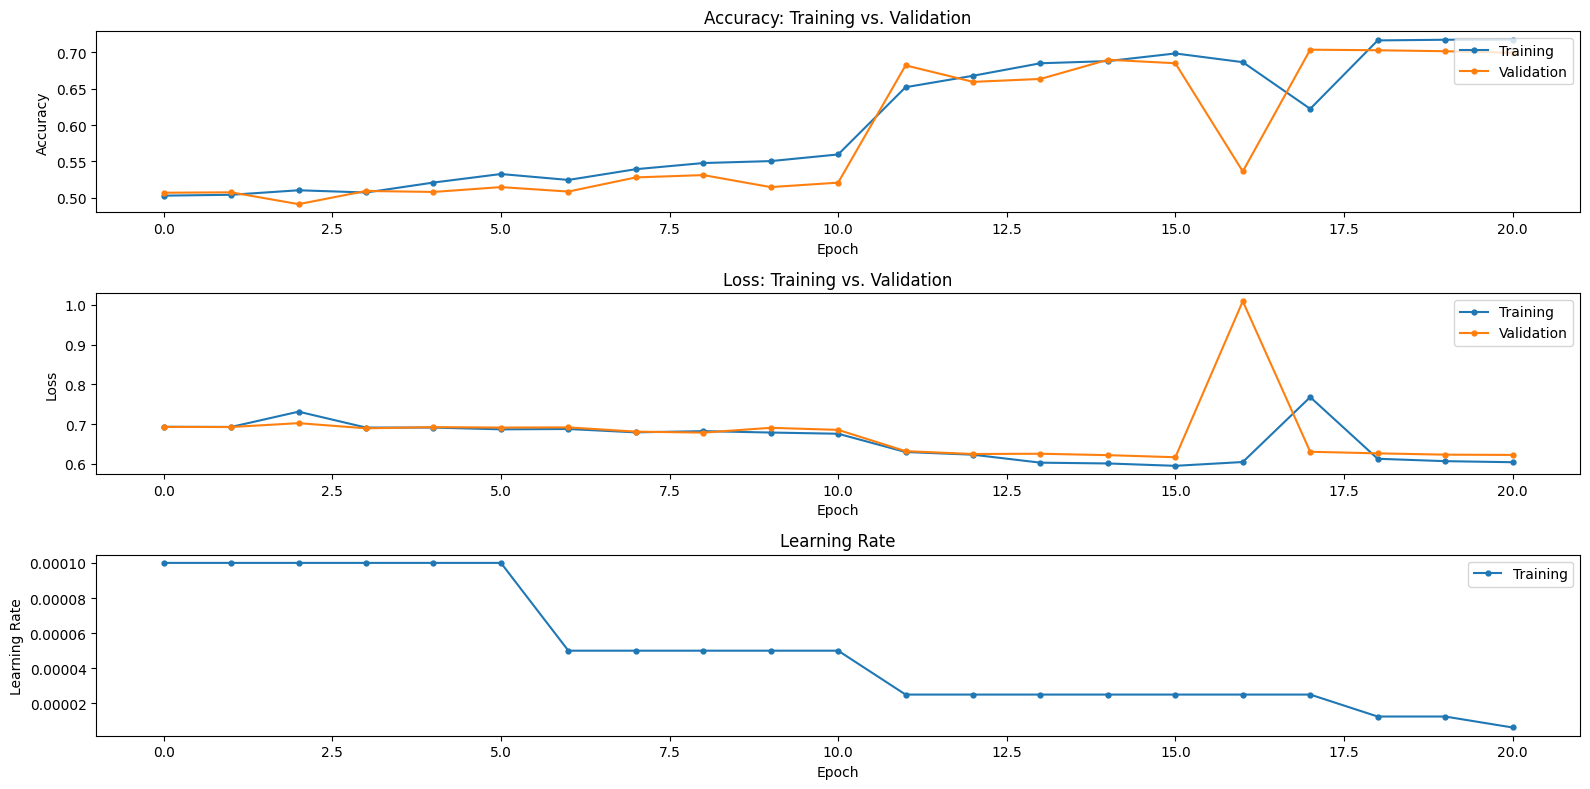

In [17]:
# Graficar Accuracy-Loss
lstm_history_df = pd.DataFrame(lstm_history.history)
plot_accuracy_loss_throught_epoch(load_lstm_history_df)

LSTM dado 30 épocas, no termina de converger y estabilizarse en la bondad.

In [18]:
# Reproduce the paper table 4
df_models_results =  pd.DataFrame(columns=["model", 'accuracy'])
df_models_results.loc[0, "model"] = 'LSTM'
df_models_results.loc[0, "accuracy"] = 0.6702
df_models_results

,model,accuracy
0,LSTM,0.6702


## 3 Modelo basado en mecanismos de atención. (2 puntos)



<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [2 pts.]:</strong>
En este ejercicio, deberás construir y entrenar una pequeña arquitectura que combine una capa de Embedding, mecanismos de atención (Multi-Head Attention), y conexiones residuales, simulando los principios básicos de los Transformers. Para ello el modelo constará:
  
    
* Entrada del modelo.
* Capa de Embedding: Utiliza una capa Embedding.
* Capa de Atención: Incorpora una capa MultiHeadAttention. Esta capa debe recibir como entrada su propia salida, simulando una atención self-attention.
* Conexión Residual: Añade la salida de la capa de atención a la salida original de la capa de embedding mediante una operación de suma (Add). Posteriormente, aplica una capa de normalización (LayerNormalization).
* Capa de Flatten y Regularización.
* Finalmente añade una última capa clasificadora de una neurona y activación sigmoide

Con esta arquitectura deberas de:
*  Mostrar el resumen del modelo y el diagrama de bloques.
*  Entrenar el modelo y obtener los resultados sobre test. Muestra las curvas de entrenamiento. Cuando entrenes el modelo, también implementa un early stopping y quédate con el modelo que te de mejores resultados en validación.
*  Comenta y discute lo que has realizado. Compara tus resultados con los obtenidos anteriormente. Amplia la tabla de resultados pedida en el ejercicio anterior. Toma las decisiones sobre los parámetros que consideres.

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

In [19]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Embedding, MultiHeadAttention, Add, LayerNormalization
from tensorflow.keras.layers import Flatten, Dropout, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

# Parameters
input_dimension = np.max(x_train) + 1 # The max vocabulary size dimension
maxlen = 400
dropout_rate= 0.2
embedded_dim = 64 # Embedding output dimension
num_attention_heads = 4

# Create a small Transformer architecture composed of
# 1. One input layer
transf_inputs = Input(shape=(maxlen,), name='Input_Layer')

# 2. One embedding layer 
transf_embedding = Embedding(input_dim=input_dimension, output_dim=embedded_dim, input_length=maxlen, name='Embedding_Layer')(transf_inputs)

# 3. Attention layer using MultiHeadAttention
transf_attention_output = MultiHeadAttention(num_heads=num_attention_heads, key_dim=embedded_dim, name='MultiHeadAttention_SelfAttention')(transf_embedding, transf_embedding)

# 4. A residual connection Add to later apply a LayerNormalization
transf_residual = Add(name='Residual_Add')([transf_embedding, transf_attention_output])
transf_normalized = LayerNormalization(name='LayerNorm')(transf_residual)

# 5. A flatten and regularization layer
transf_flattened = Flatten(name='Flatten')(transf_normalized)
transf_dropout = Dropout(rate=dropout_rate, name='Dropout')(transf_flattened)

# 6. An output classification layer using sigmoid (binary classification)
transf_outputs = Dense(1, activation='sigmoid', name='Output_Layer')(transf_dropout)

# Initialize the model
transformer_basic_model = Model(inputs=transf_inputs, outputs=transf_outputs, name='Transformer_Sentiment_Classifier')

# Complile transformer_basic_model
transformer_basic_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                          loss='binary_crossentropy',
                          metrics=['accuracy'])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [20]:
# Callbacks
transf_early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
transf_checkpoint_path = '/kaggle/working/trasnformer_basic_checkpoint.model.keras'
transf_model_checkpoint = ModelCheckpoint('trasnformer_basic_checkpoint.model.keras', monitor='val_loss', save_best_only=True)
transf_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)

# Show model summary
transformer_basic_model.summary()

Model: "Transformer_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)  │ (None, 400)            │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Embedding_Layer           │ (None, 400, 64)        │      5,669,568 │ Input_Layer[0][0]      │
│ (Embedding)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ MultiHeadAttention_SelfA… │ (None, 400, 64)        │         66,368 │ Embedding_Layer[0][0], │
│ (MultiHeadAttention)      │                        │                │ Embedding_Layer[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Residual_Add (Add)        │ (None, 400, 64)        │              0 │ Embedding_Layer[0][0], │
│                           │                        │                │ MultiHeadAttention_Se… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ LayerNorm                 │ (None, 400, 64)        │            128 │ Residual_Add[0][0]     │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Flatten (Flatten)         │ (None, 25600)          │              0 │ LayerNorm[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Dropout (Dropout)         │ (None, 25600)          │              0 │ Flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Output_Layer (Dense)      │ (None, 1)              │         25,601 │ Dropout[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 5,761,665 (21.98 MB)

 Trainable params: 5,761,665 (21.98 MB)

 Non-trainable params: 0 (0.00 B)

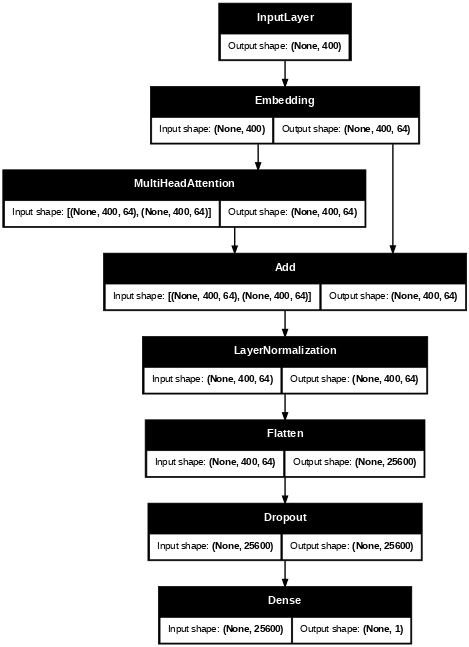

In [21]:
# Show model diagram
tf.keras.utils.plot_model(transformer_basic_model, show_shapes=True, expand_nested=True, dpi=50)

In [22]:
# Train the Transformer Basic secuential model
import time
transf_basic_start_time = time.time()
transformer_basic_history = transformer_basic_model.fit(
    x_train_deducted, y_train_deducted,
    validation_data=(x_validation, y_validation),
    epochs=30,
    batch_size=50,
    callbacks=[transf_early_stopping, transf_model_checkpoint, transf_reduce_lr]
)
transf_basic_end_time = time.time()
transf_basic_total_time =  transf_basic_end_time - transf_basic_start_time
print(f"Tiempo de entrenamiento: {transf_basic_total_time:.2f} segundos")

Epoch 1/30


I0000 00:00:1747598626.320676     118 service.cc:148] XLA service 0x7c1f7548d530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747598626.323156     118 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1747598626.323178     118 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


  7/425 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.5196 - loss: 0.8600

I0000 00:00:1747598629.555620     118 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


425/425 ━━━━━━━━━━━━━━━━━━━━ 17s 24ms/step - accuracy: 0.5217 - loss: 0.7706 - val_accuracy: 0.5664 - val_loss: 0.6969 - learning_rate: 1.0000e-04
Epoch 2/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.7197 - loss: 0.5563 - val_accuracy: 0.6787 - val_loss: 0.5949 - learning_rate: 1.0000e-04
Epoch 3/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.8654 - loss: 0.3474 - val_accuracy: 0.7587 - val_loss: 0.4780 - learning_rate: 1.0000e-04
Epoch 4/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9254 - loss: 0.2168 - val_accuracy: 0.8501 - val_loss: 0.3527 - learning_rate: 1.0000e-04
Epoch 5/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - accuracy: 0.9651 - loss: 0.1250 - val_accuracy: 0.8635 - val_loss: 0.3286 - learning_rate: 1.0000e-04
Epoch 6/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9762 - loss: 0.0870 - val_accuracy: 0.8595 - val_loss: 0.3503 - learning_rate: 1.0000e-04
Epoch 7/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 10s 25ms/step - accurac

In [23]:
# Save training time with GPU only
transf_basic_total_time = round(128.92/60,2)
print(f"Transformer basic training: {transf_basic_total_time} minutes")

Transformer basic training: 2.15 minutes


In [24]:
# Evaluate Transformer Basic on testing set
# transf_basic_test_loss, transf_basic_test_acc = transformer_basic_model.evaluate(x_test, y_test)
# print(f"Test Loss: {transf_basic_test_loss:.4f}, Test Accuracy: {transf_basic_test_acc:.4f}")

# Save in a dictionary the validation results
transf_basic_model_validation = {"accuracy":0.8548, "loss":0.3573}
print(f"Test Accuracy: {transf_basic_model_validation['accuracy']} Test Loss: {transf_basic_model_validation['loss']}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8557 - loss: 0.3520
Test Loss: 0.3573, Test Accuracy: 0.8548
Test Accuracy: 0 Test Loss: 0


**Exportar modelo entrenado como historial de entrenamiento**

In [25]:
# Save the trained model in directory
# from tensorflow.keras.models import load_model

# Save the trained model
# path_save_transf_basic_model = os.path.join(file_storage_root_directory, "transf_basic_trained_model.keras")
# transformer_basic_model.save(path_save_transf_basic_model)

# Save training history as csv
path_save_transf_basic_history = os.path.join(file_storage_root_directory, 'transf_basic_training_history.csv')
transf_basic_history_df = pd.DataFrame(transformer_basic_history.history)
transf_basic_history_df.to_csv(path_save_transf_basic_history)

**Importar modelo entrenado como historial de entrenamiento**

In [ ]:
# Load the file containing the model
# loaded_transf_basic_model = load_model(path_save_transf_basic_model)
# loaded_transf_basic_model.summary()

In [26]:
# Load the history results of the model
load_transf_basic_history_df = pd.read_csv(path_save_transf_basic_history)
load_transf_basic_history_df.head(5)

,Unnamed: 0,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0,0.530918,0.753169,0.566400,0.696891,0.0001
1,1,0.733976,0.535247,0.678667,0.594877,0.0001
2,2,0.873318,0.324953,0.758667,0.477971,0.0001
3,3,0.929788,0.203809,0.850133,0.352703,0.0001
4,4,0.961459,0.127345,0.863467,0.328645,0.0001


/tmp/ipykernel_35/4040253700.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


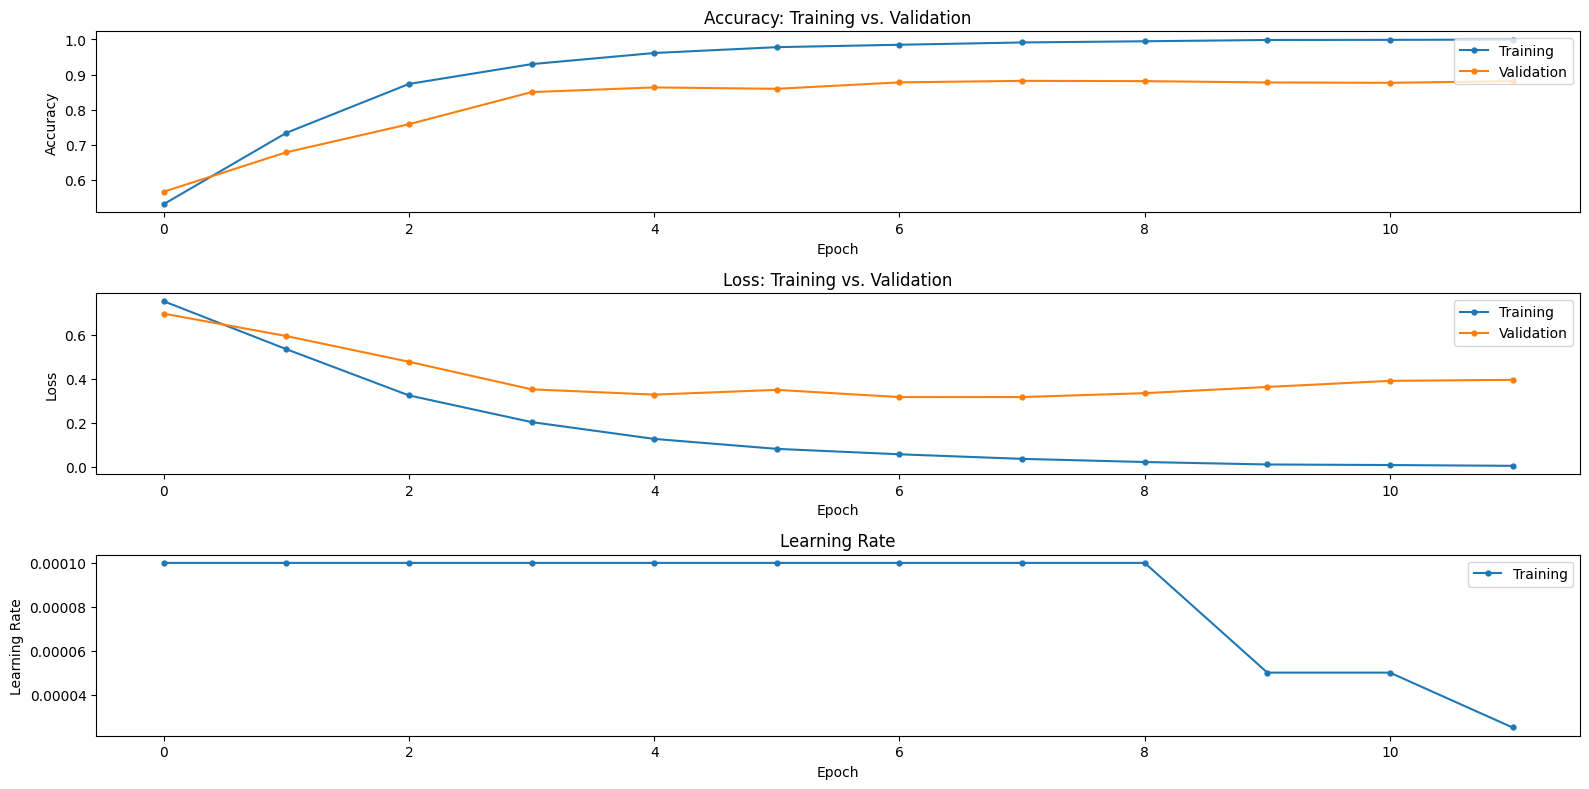

In [27]:
# Plot Accuracy-Loss
plot_accuracy_loss_throught_epoch(load_transf_basic_history_df)

Las curvas de accuracy sugieren que hay cierto sobrentrenamiento pero converge y se estabiliza mejor que en el caso de LSTM. La bondad sobre el conjunto de entrenamiento es mucho mayor que en el conjunto de validación, sin cambios en la curva de aprendizaje apenas.

In [28]:
# Reproduce the paper table 4
df_models_results.loc[1, "model"] = 'Transformer Basic'
df_models_results.loc[1, "accuracy"] = 0.8548
df_models_results

,model,accuracy
0,LSTM,0.6702
1,Transformer Basic,0.8548


**Conclusión**

Con los resultado obtenidos se demuestra que dado el mismo conjunto de datos como valor de parámetros comunes (learning rate, epoch, patience, output dimension, drop out), la arquitectura de transformadores comprende mejor la complejidad semántica pudiendo separar los textos en positivo o negativo que la red LSTM. Sin ningún tipo de optimización 0.85 de accuracy para 30 épocas.

## 4 Modelo basado en mecanismos de atención mejorado. (0.5 puntos)



<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.5 pts.]:</strong>
Realiza alguna modificación sobre la arquitectura anterior y reentrena el modelo. Algunas ideas pueden ser: añadir varias cabezas de atención, modificar los residuos, incluir alguna capa recurrente, etc. Discute la decisión tomada y añade el resultado sobre el conjunto de test en la tabla de resultados.

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

En este segundo modelo hemos aplicado dos cabezas de atención adicionales con el fin de facilitar el enfoque del modelo en distintas partes de la secuencia (texto) de forma simulatánea para así capturar por ejemplo sarcasmos or redundancias. Por otra parte hemos añadido una capa más de atención, con el objetivo de capturar las relaciones (palabras) de larga dependencia como los ejemplos dados en el paper.

In [30]:
# Parameters
input_dimension = np.max(x_train) + 1 # The max vocabulary size dimension
maxlen = 400
dropout_rate= 0.2
embedded_dim = 64 # Embedding output dimension
num_attention_heads = 6 # Increase 2 attention heads

# Create a improved Transformer architecture composed of
# 1. One input layer
m1_transf_inputs = Input(shape=(maxlen,), name='Input_Layer')

# 2. One embedding layer 
m1_transf_embedding = Embedding(input_dim=input_dimension, 
                             output_dim=embedded_dim, 
                             input_length=maxlen,
                             name='Embedding_Layer')(m1_transf_inputs)

# 3.1 First Multi-Head Self-Attention Block + Residual + LayerNorm
m1_transf_attention_output_1 = MultiHeadAttention(num_heads=num_attention_heads, 
                                               key_dim=embedded_dim,
                                               name='MultiHeadAttention_SelfAttention_Block1')(m1_transf_embedding, m1_transf_embedding)

m1_transf_residual_1 = Add(name='Residual_Add_1')([m1_transf_embedding, m1_transf_attention_output_1])
m1_transf_normalized_1 = LayerNormalization(name='LayerNorm_1')(m1_transf_residual_1)

# 3.2 Second Multi-Head Self-Attention Block + Residual + LayerNorm
m1_transf_attention_output_2 = MultiHeadAttention(num_heads=num_attention_heads,
                                               key_dim=embedded_dim,
                                               name='MultiHeadAttention_SelfAttention_Block2')(m1_transf_normalized_1, m1_transf_normalized_1)
m1_transf_residual_2 = Add(name='Residual_Add_2')([m1_transf_normalized_1, m1_transf_attention_output_2])
m1_transf_normalized_2 = LayerNormalization(name='LayerNorm_2')(m1_transf_residual_2)

# 5. A flatten and regularization layer
m1_transf_flattened = Flatten(name='Flatten')(m1_transf_normalized_2)
m1_transf_dropout = Dropout(rate=dropout_rate, name='Dropout')(m1_transf_flattened)

# 6. An output classification layer using sigmoid (binary classification)
m1_transf_outputs = Dense(1, activation='sigmoid', name='Output_Layer')(m1_transf_dropout)

# Initialize the model
transformer_improved_model = Model(inputs=m1_transf_inputs,
                                outputs=m1_transf_outputs,
                                name='Improved_Transformer_Sentiment_Classifier')

# Complile transformer_basic_model
transformer_improved_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                          loss='binary_crossentropy',
                          metrics=['accuracy'])

In [31]:
# Callbacks
m1_transf_early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
m1_transf_checkpoint_path = '/kaggle/working/trasnformer_improved_checkpoint.model.keras'
m1_transf_model_checkpoint = ModelCheckpoint('trasnformer_improved_checkpoint.model.keras', monitor='val_loss', save_best_only=True)
m1_transf_reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1, min_lr=1e-6)

# Show model summary
transformer_improved_model.summary()

Model: "Improved_Transformer_Sentiment_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)  │ (None, 400)            │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Embedding_Layer           │ (None, 400, 64)        │      5,669,568 │ Input_Layer[0][0]      │
│ (Embedding)               │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ MultiHeadAttention_SelfA… │ (None, 400, 64)        │         99,520 │ Embedding_Layer[0][0], │
│ (MultiHeadAttention)      │                        │                │ Embedding_Layer[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Residual_Add_1 (Add)      │ (None, 400, 64)        │              0 │ Embedding_Layer[0][0], │
│                           │                        │                │ MultiHeadAttention_Se… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ LayerNorm_1               │ (None, 400, 64)        │            128 │ Residual_Add_1[0][0]   │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ MultiHeadAttention_SelfA… │ (None, 400, 64)        │         99,520 │ LayerNorm_1[0][0],     │
│ (MultiHeadAttention)      │                        │                │ LayerNorm_1[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Residual_Add_2 (Add)      │ (None, 400, 64)        │              0 │ LayerNorm_1[0][0],     │
│                           │                        │                │ MultiHeadAttention_Se… │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ LayerNorm_2               │ (None, 400, 64)        │            128 │ Residual_Add_2[0][0]   │
│ (LayerNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Flatten (Flatten)         │ (None, 25600)          │              0 │ LayerNorm_2[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Dropout (Dropout)         │ (None, 25600)          │              0 │ Flatten[0][0]          │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ Output_Layer (Dense)      │ (None, 1)              │         25,601 │ Dropout[0][0]          │
└───────────────────────────┴────────────────────────┴────────────────┴────────────────────────┘

 Total params: 5,894,465 (22.49 MB)

 Trainable params: 5,894,465 (22.49 MB)

 Non-trainable params: 0 (0.00 B)

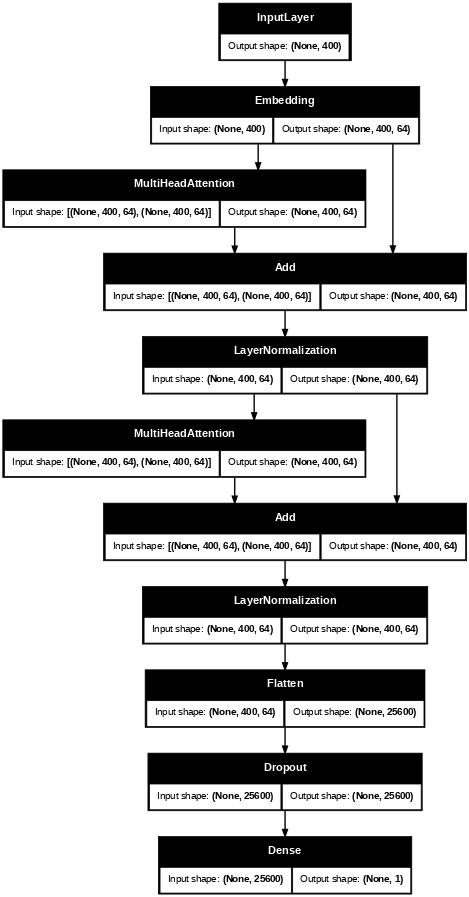

In [32]:
# Show model diagram
tf.keras.utils.plot_model(transformer_improved_model, show_shapes=True, expand_nested=True, dpi=50)

In [33]:
# Train the Improved Transformer model
import time
m1_transf_start_time = time.time()
transformer_improved_history = transformer_improved_model.fit(
    x_train_deducted, y_train_deducted,
    validation_data=(x_validation, y_validation),
    epochs=30,
    batch_size=50,
    callbacks=[m1_transf_early_stopping, m1_transf_model_checkpoint, m1_transf_reduce_lr]
)
m1_transf_end_time = time.time()
m1_transf_total_time =  m1_transf_end_time - m1_transf_start_time
print(f"Tiempo de entrenamiento: {m1_transf_total_time:.2f} segundos")

Epoch 1/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 42s 77ms/step - accuracy: 0.5086 - loss: 0.8534 - val_accuracy: 0.5597 - val_loss: 0.7138 - learning_rate: 1.0000e-04
Epoch 2/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 30s 70ms/step - accuracy: 0.6905 - loss: 0.5799 - val_accuracy: 0.7560 - val_loss: 0.5081 - learning_rate: 1.0000e-04
Epoch 3/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - accuracy: 0.8856 - loss: 0.2879 - val_accuracy: 0.8128 - val_loss: 0.4101 - learning_rate: 1.0000e-04
Epoch 4/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 31s 73ms/step - accuracy: 0.9487 - loss: 0.1563 - val_accuracy: 0.8331 - val_loss: 0.3830 - learning_rate: 1.0000e-04
Epoch 5/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 30s 72ms/step - accuracy: 0.9752 - loss: 0.0867 - val_accuracy: 0.8600 - val_loss: 0.3571 - learning_rate: 1.0000e-04
Epoch 6/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 30s 71ms/step - accuracy: 0.9886 - loss: 0.0484 - val_accuracy: 0.8499 - val_loss: 0.4001 - learning_rate: 1.0000e-04
Epoch 7/30
425/425 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step

In [34]:
# Save training time with GPU only
transf_improved_total_time = round(314.11/60,2)
print(f"Transformer basic training: {transf_improved_total_time} minutes")

Transformer basic training: 5.24 minutes


In [35]:
# Evaluate Improved Transformer on testing set
transf_improved_test_loss, transf_improved_test_acc = transformer_improved_model.evaluate(x_test, y_test)
print(f"Test Loss: {transf_improved_test_loss:.4f}, Test Accuracy: {transf_improved_test_acc:.4f}")

# Save in a dictionary the validation results
transf_improved_validation = {"accuracy":0.8453, "loss":0.3733}
print(f"Test Accuracy: {transf_improved_validation['accuracy']} Test Loss: {transf_improved_validation['loss']}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 14s 16ms/step - accuracy: 0.8475 - loss: 0.3710
Test Loss: 0.3733, Test Accuracy: 0.8453
Test Accuracy: 0 Test Loss: 0


**Exportar modelo entrenado como historial de entrenamiento**

In [36]:
# Save the trained model in directory
# from tensorflow.keras.models import load_model

# Save the trained model
# path_save_transf_improved_model = os.path.join(file_storage_root_directory, "transf_improved_trained_model.keras")
# transformer_improved_model.save(path_save_transf_improved_model)

# Save training history as csv
path_save_transf_improved_history = os.path.join(file_storage_root_directory, 'transf_improved_training_history.csv')
transf_improved_history_df = pd.DataFrame(transformer_improved_history.history)
transf_improved_history_df.to_csv(path_save_transf_improved_history)

**Importar modelo entrenado como historial de entrenamiento**

In [ ]:
# Load the file containing the model
# loaded_transf_improved_model = load_model(path_save_transf_improved_model)
# loaded_transf_improved_model.summary()

In [37]:
# Load the history results of the model
load_transf_improved_history_df = pd.read_csv(path_save_transf_improved_history)
load_transf_improved_history_df.head(5)

,Unnamed: 0,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0,0.517318,0.830652,0.559733,0.713841,0.0001
1,1,0.722212,0.541506,0.756000,0.508092,0.0001
2,2,0.890212,0.272181,0.812800,0.410128,0.0001
3,3,0.947812,0.153287,0.833067,0.382995,0.0001
4,4,0.975012,0.085206,0.860000,0.357076,0.0001


/tmp/ipykernel_35/4040253700.py:41: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


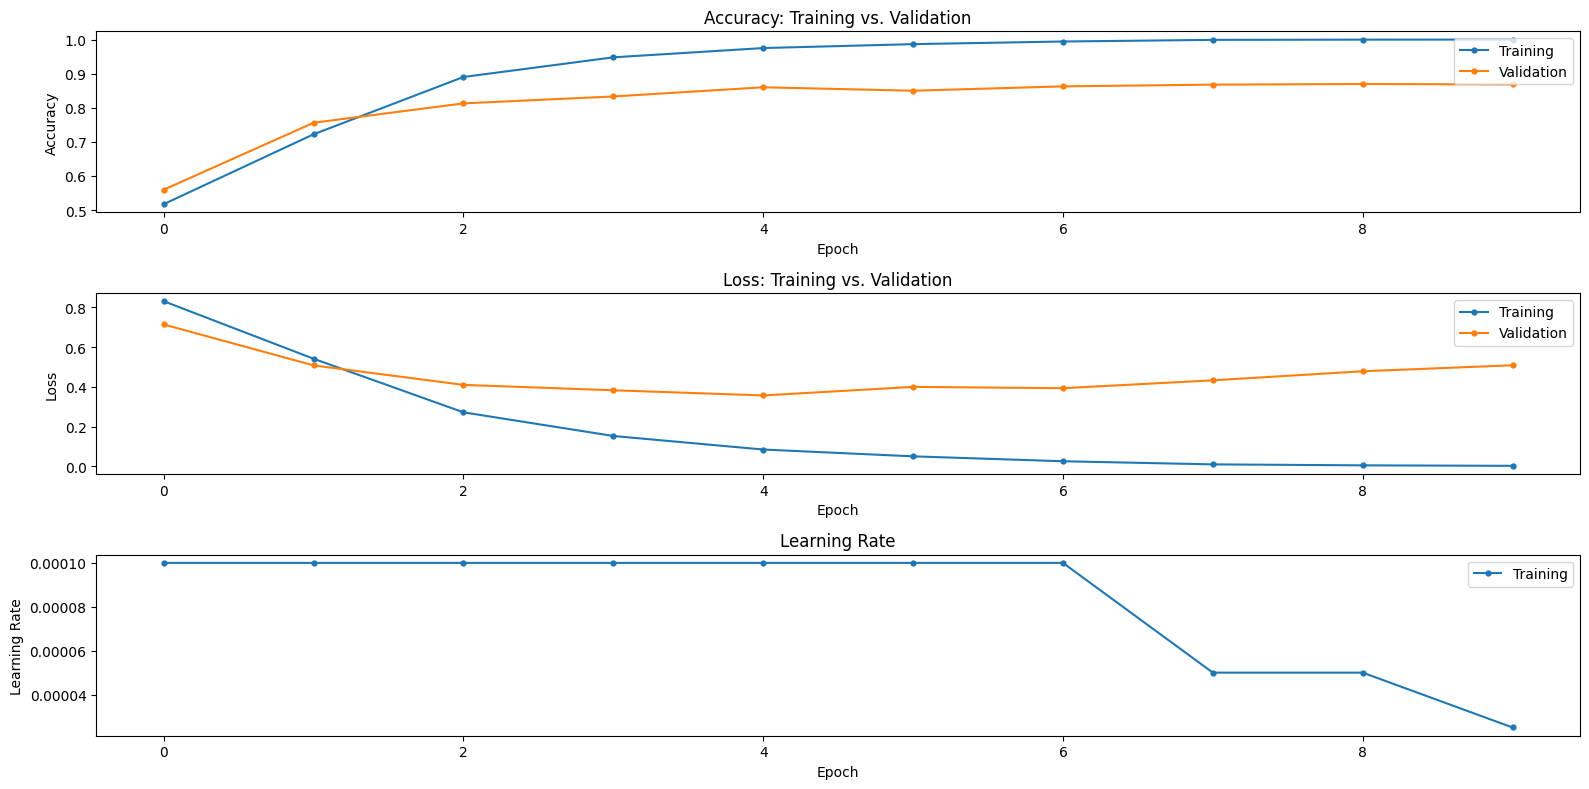

In [38]:
# Plot Accuracy-Loss
plot_accuracy_loss_throught_epoch(load_transf_improved_history_df)

In [39]:
# Reproduce the paper table 4
df_models_results.loc[2, "model"] = 'Transformer Improved'
df_models_results.loc[2, "accuracy"] = 0.8453
df_models_results

,model,accuracy
0,LSTM,0.6702
1,Transformer Basic,0.8548
2,Transformer Improved,0.8453


**Conclusión**

Con los resultado obtenidos se demuestra que dado el mismo conjunto de datos como valor de parámetros comunes como (learning rate, epoch, patience, output dimension, drop out), la arquitectura de transformadores comprende mejor la complejidad semántica pudiendo separar los textos en positivo o negativo que la red LSTM.
Si comparamos la versión básica de transformadores con la versión mejorada (con más mecanismos de atención), obtenemos un peor rendimiento. Con lo cual, consideramos que la arquitectura creada es adecuada para el conjunto de datos que contamos. Mas cabezas de atención requerirían más datos a imputar.

In [ ]:
# Fail here to restart the session to continue next excercises
print("=========================================END=========================================")
print("Paramos el proceso para reiniciar el entorno para realizar los ejercicios sobre modelos downstream")
1=0

In [ ]:
#import os
#file_storage_root_directory = "/kaggle/working/"
#for name in os.listdir():
#    file = os.path.join(file_storage_root_directory, name)
#    if os.path.isfile(file):
#        os.remove(file)

# Ejercicios 5 a 7

## Carga de librerías

Notas del profesorado. A partir del apartado 5, es necesario reiniciar el entorno y añadir estas líneas de código para instalar las dependencias necesarias:

In [1]:
# import os
# os.environ['TF_USE_LEGACY_KERAS'] = '1'
# !pip install tf-models-official==2.18.0 --upgrade

!pip install -q tensorflow==2.14.0 --upgrade
!pip install -q tensorflow_text==2.14.0 --upgrade
!pip install -q tf-models-official==2.14.0 --upgrade
!pip install -q keras==2.14.0 --upgrade
!pip install -q tensorflow-estimator==2.14.0 --upgrade
!pip install -q tensorflow-hub==0.16.1 --upgrade
!pip install -q tensorflow-datasets==4.9.2 --upgrade
!pip install -q tensorflow-metadata==1.14.0 --upgrade
!pip install -q tensorflow-io-gcs-filesystem==0.37.1 --upgrade

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 489.9/489.9 MB 2.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 33.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 81.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440.7 kB 24.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 3.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-decision-forests 1.11.0 requires tensorflow==2.18.0, but you have tensorflow 2.14.0 which is incompatible.
jax 0.5.2 requires ml_dtypes>=0.4.0, but you have ml-dtypes 0.2.0 which is incompatible.
dopamine-rl 4.1.2 requires gymnasium>=1.0.0, but you have gymnasium 0.29.0 which is incompatible.
tf-keras 2.18.0 requires tensorf

Después de esto, pueden verificar la configuración ejecutando este código:

In [2]:
import tensorflow as tf
import tensorflow_hub as hub
import tensorflow_text as text 
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt

print("Versión de TensorFlow:", tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))
if gpus:
    print("GPUs detectadas:", gpus)
    details = tf.config.experimental.get_device_details(gpus[0])
    print("Detalles de GPU:", details)
else:
    print("No se detectó GPU")

print(hub.__version__)
print(text.__version__)

2025-05-18 20:24:38.284767: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-18 20:24:38.285591: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-18 20:24:38.285640: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Versión de TensorFlow: 2.14.0
Num GPUs Available: 0
No se detectó GPU
0.16.1
2.14.0


Deberían ver algo como:

In [3]:
version_compare = """
Versión de TensorFlow: 2.14.0
Num GPUs Available: 0
No se detectó GPU
0.16.1
2.14.0
"""
print(version_compare)


Versión de TensorFlow: 2.14.0
Num GPUs Available: 0
No se detectó GPU
0.16.1
2.14.0



Volvemos a importar los paquetes requeridos

In [4]:
# We import the packages
import tensorflow as tf
import keras
from transformers import BertTokenizer, TFBertModel

from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense, Embedding, GlobalAveragePooling1D
from keras.layers import LSTM, SimpleRNNCell, Flatten, Dropout, MultiHeadAttention, Bidirectional, TimeDistributed, Dense, Embedding
from tensorflow.keras.layers import Permute, dot, add, concatenate
from tensorflow.keras.utils import plot_model
from tensorflow.keras.callbacks import ModelCheckpoint,EarlyStopping,ReduceLROnPlateau


from tensorflow.keras.preprocessing.sequence import pad_sequences

import tensorflow_hub as hub
import tensorflow_text as text
from official.nlp import optimization

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import time

### Load & Process IMDB Data

In [5]:
# Import the IMDB module
from tensorflow.keras.datasets import imdb

# Use the default parameters in keras.datasets.imdb.load_data
num_words = None
start_char = 1 
oov_char = 2
index_from = 3

# Retrieve the training and testing sequences
(x_training, y_training), (x_testing, y_testing)  = imdb.load_data(num_words=num_words, start_char=start_char, oov_char=oov_char, index_from=index_from)

17464789/17464789 [==============================] - 0s 0us/step


In [6]:
# Let's review how the data is presented
print("\nx training data type: \n", x_training[:1])
print("\ny training data type: \n", y_training[0:5])
print("\nx testing data type: \n", x_testing[:1])
print("\ny testing data type: \n", y_testing[0:5])

# Each word of the review is encoded with indexes [1, 14, 22, 16 ...]
# And the classification labels are encoded as 1 or 0


x training data type: 
 [list([1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 22665, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 21631, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 19193, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 10311, 8, 4, 107, 117, 5952, 15, 256, 4, 31050, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 12118, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32])]

y 

In [7]:
# Let's review the container of the data
print("\nx training size: \n", x_training.shape)
print("\ny training size: \n", y_training.shape)
print("\nx testing size: \n", x_testing.shape)
print("\ny testing size: \n", y_testing.shape)


x training size: 
 (25000,)

y training size: 
 (25000,)

x testing size: 
 (25000,)

y testing size: 
 (25000,)


In [8]:
# Reverse the dictionary from {Key: Value} to {Value: Key} to decode to text
# {'fawn': 34701} -> {34701: 'fawn'}
word_index = imdb.get_word_index()
reverse_word_index = {value: key for key, value in word_index.items()}

# Mini function to decode the numerical sequence in the dataset to a text type
def decode_sequence(encoded_review):
    return ' '.join([reverse_word_index.get(i-3, '?') for i in encoded_review])
    
# Store the reviews as text
x_training_text = []
y_training_label = []


for review, label in zip(x_training, y_training):
    x_training_text.append(decode_sequence(review))
    y_training_label.append(label)

x_testing_text = []
y_testing_label = []

for review, label in zip(x_testing, y_testing):
    x_testing_text.append(decode_sequence(review))
    y_testing_label.append(label)
    
# Example of decoded review back to text
print("\n=======TRAINING=========\n")
print("Decoded to text:\n ", x_training_text[0])
print("\nLabel: ", y_training_label[0])

print("\n=======TESTING=========\n")
print("Decoded to text:\n ", x_testing_text[0])
print("\nLabel: ", y_testing_label[0])

1641221/1641221 [==============================] - 0s 0us/step

=======TRAINING=========

Decoded to text:
  ? this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert redford's is an amazing actor and now the same being director norman's father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for retail and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also congratulations to the two little boy's that played the part's of norman and paul they were just brilliant children are often left out of the praising list i think because the stars that 

In [9]:
# Let's review the container of the data
print("\nx training size: \n", len(x_training_text))
print("\ny training size: \n", len(y_training_label))
print("\nx testing size: \n", len(x_testing_text))
print("\ny testing size: \n", len(y_testing_label))

# It's a list


x training size: 
 25000

y training size: 
 25000

x testing size: 
 25000

y testing size: 
 25000


In [10]:
# Split the text into validation and test
validation_split = 0.15
validation_samples = int(validation_split * len(x_training_text))

x_validation_text = x_training_text[:validation_samples]
y_validation_label = y_testing_label[:validation_samples]

x_train_text = x_training_text[validation_samples:]
y_train_label = y_testing_label[validation_samples:]

# Let's review final input data length
print(f"""
x training size: {len(x_train_text)}
y training size: {len(y_train_label)}
x validation size: {len(x_validation_text)}
y validation size: {len(y_validation_label)}
x testing size: {len(x_testing_text)}
y testing size: {len(y_testing_label)}
""")


x training size: 21250
y training size: 21250
x validation size: 3750
y validation size: 3750
x testing size: 25000
y testing size: 25000



In [11]:
# Convert the lists into TensorFlow tf.data.Dataset type

# FULL SIZE
# batch_size = 16
# AUTOTUNE = tf.data.AUTOTUNE

# Convert lists in pairs of (review,label) and adequate imput for model
# train_ds = tf.data.Dataset.from_tensor_slices((x_train_text, y_train_label)).batch(batch_size=batch_size).prefetch(buffer_size=AUTOTUNE)
# val_ds = tf.data.Dataset.from_tensor_slices((x_validation_text, y_validation_label)).batch(batch_size=batch_size).prefetch(buffer_size=AUTOTUNE)
# test_ds = tf.data.Dataset.from_tensor_slices((x_testing_text, y_testing_label)).batch(batch_size=batch_size).prefetch(buffer_size=AUTOTUNE)

# REDUCED SIZE
# We work with a reduced sample to achieve 10 epochs
x_train_tiny = x_train_text[0:1000]
y_train_tiny = y_train_label[0:1000]
x_validation_tiny = x_validation_text[0:100]
y_validation_tiny = y_validation_label[0:100]
x_testing_tiny = x_testing_text[0:100]
y_testing_tiny = y_testing_label[0:100]

# Batch size is also reduced to the minimum
batch_size = 16
AUTOTUNE = tf.data.AUTOTUNE

# Convert lists in pairs of (review,label) and adequate imput for model
train_ds_tiny = tf.data.Dataset.from_tensor_slices((x_train_tiny, y_train_tiny)).batch(batch_size=batch_size).prefetch(buffer_size=AUTOTUNE)
val_ds_tiny = tf.data.Dataset.from_tensor_slices((x_validation_tiny, y_validation_tiny)).batch(batch_size=batch_size).prefetch(buffer_size=AUTOTUNE)
test_ds_tiny = tf.data.Dataset.from_tensor_slices((x_testing_tiny, y_testing_tiny)).batch(batch_size=batch_size).prefetch(buffer_size=AUTOTUNE)

In [12]:
# Let's take a look to a few reviews
for text_batch, label_batch in train_ds_tiny.take(1):
  for i in range(2):
    print(f'Review: {text_batch.numpy()[i]}')
    label = label_batch.numpy()[i]
    print(f'Label: {label}')

Review: b"? i sat through this movie this evening forcing myself to stick with it even though i never cared about any of the characters or what happened to them because the two leads g\xc3\xa9rard philippe and mich\xc3\xa8le morgan were major film stars of their era and i wanted to see them in something different which this certainly was they both gave fine performances but of distasteful characters br br indeed the whole movie is about a shabby little town in mexico inhabited by almost uniformly distasteful characters the doctor is of course the major exception what mich\xc3\xa8le morgan ever sees in philippe to fall in love with him is never explained br br this is supposedly based on a work by jean paul sartre all i could think was that if sartre's work is anything like this movie it must be a very mediocre attempt at imitating camus' masterful novel the plague which dealt with a plague in north africa br br a well acted but uninteresting movie"
Label: 0
Review: b"? previous comment

In [13]:
# Function to plot the training results
# Plot the accuracy and loss functions
import pandas as pd
def plot_accuracy_loss_throught_epoch(df_history:pd.DataFrame):
    """Graficar las métricas de bondad de forma conjunta"""
    acc = df_history['binary_accuracy']
    val_acc = df_history['val_binary_accuracy']
    loss = df_history['loss']
    val_loss = df_history['val_loss']
    learning_rate = df_history['lr']

    epochs_range = range(len(acc))

    plt.figure(figsize=(16, 8))

    # Plot Accuracy
    plt.subplot(3, 1, 1)
    plt.plot(epochs_range, acc, label='Training', marker='.', markersize=7)
    plt.plot(epochs_range, val_acc, label='Validation', marker='.', markersize=7)
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.title('Accuracy: Training vs. Validation')

    # Plot Loss
    plt.subplot(3, 1, 2)
    plt.plot(epochs_range, loss, label='Training',  marker='.', markersize=7)
    plt.plot(epochs_range, val_loss, label='Validation',  marker='.', markersize=7)
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.title('Loss: Training vs. Validation')
    plt.tight_layout()

    # plot Learning Rate
    plt.subplot(3, 1, 3)
    plt.plot(epochs_range, learning_rate, label='Training',  marker='.', markersize=7)
    plt.ylabel('Learning Rate')
    plt.xlabel('Epoch')
    plt.legend(loc='upper right')
    plt.title('Learning Rate')
    plt.tight_layout()

    plt.show()

## 5 Downstream model. (3 puntos)
Un modelo downstream (o tarea downstream) es un modelo o tarea que utiliza un modelo preentrenado en una fase anterior, a menudo conocida como fase de preentrenamiento, para resolver una tarea específica. Este modelo posteriormente se utiliza mediante un entrenamiento específico para resolver una tarea distinta. Si la tarea tiene características similares y la arquitectura de la red es lo suficientemente compleja como para captar los fundamentos compartidos, es una estrategia que trae muchas ventajas.

Una de las grandes ventajas de los Transformers es su escalabilidad. Para entender esto se recomienda ampliar los conocimientos con algunos recursos divulgativos como los siguientes:
* https://www.youtube.com/watch?v=EFkbT-1VGTQ
* https://www.fabricatedknowledge.com/p/ai-foundations-part-1-transformers
* https://www.baeldung.com/cs/rnns-transformers-nlp


<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [2 pt]:</strong>

En este ejercicio vamos a tomar los datos que hemos utilizado hasta ahora y vamos a realizar un downstream model del modelo BERT. Esta parte está mostrada en el siguiente tutorial: https://www.tensorflow.org/text/tutorials/classify_text_with_bert

Deberás adaptarla para trabajar con los datos que hemos cargado anteriormente. Elige la versión del modelo que consideres y toma las decisiones adecuadas justificándolas posteriormente. La principal dificultad en este ejercicio reside en adaptar el código del tutorial a los datos y particiones que has cargado durante el ejercicio. Para ello:
* Entrena un modelo con la arquitectura BERT más pequeña mostrada en el tutorial anterior. Elije adecuadamente el número de épocas y controla el entrenamiento con un early stopping
* Muestra el resumen del modelo con el número de parámetros
* Muestra las gráficas de entrenamiento y validación.
* Finalmente completa la tabla de resultados y muéstrala

</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

Vamos a usar la versión ligera BERTs (Small BERTs). El principal problema es el recurso computacional, seguida del tiempo de dedicación a la prueba, y en último lugar la implementación técnica dadas las incompatibilidades. Las distintas versiones de Small BERTs han demostrado buen equilibrio entre velocidad computacional como resultados (accuracy) a alcanzar. Así en este apartado vamos a usar las siguientes versiones:
- _Modelo 1: Small BERTs con la configuración [L=4 hidden layers, hidden size of H=512, A=8 attention heads]_
- _Modelo 2: Small BERTs con la configuración [L=6 hidden layers, hidden size of H=768, A=12 attention heads]_


In [14]:
# Given available models in map_name_to_handle: https://www.tensorflow.org/text/tutorials/classify_text_with_bert
# We choose Small BERT
# It uses L=4 hidden layers (i.e., Transformer blocks), a hidden size of H=512, and A=8 attention heads.
m1_model_berts = 'small_bert/bert_en_uncased_L-4_H-512_A-8'  
m1_map_name_to_handle = {'small_bert/bert_en_uncased_L-4_H-512_A-8':'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-4_H-512_A-8/1'}
m1_map_model_to_preprocess = {'small_bert/bert_en_uncased_L-4_H-512_A-8':'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3'}

m1_tfhub_handle_encoder_berts = m1_map_name_to_handle[m1_model_berts]
m1_tfhub_handle_preprocess_berts = m1_map_model_to_preprocess[m1_model_berts]

# Construct binary text classification with BERTs
def m1_build_berts_classifier_model():
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text_input')
    
    # Load the Small BERT model for preprocessing from TF Hub into a Keras model
    preprocessing_layer = hub.KerasLayer(m1_tfhub_handle_preprocess_berts, name='BERTs_preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    
    # Load the Small BERT model for encoding from TF Hub into a Keras model
    encoder = hub.KerasLayer(m1_tfhub_handle_encoder_berts, trainable=True, name='BERTs_encoder')
    outputs = encoder(encoder_inputs)
    
    # pooled_output represents each input sequence as whole
    # Think of this as an embedding for the entire movie review
    net = outputs['pooled_output'] # [Batch size, H]
    net = tf.keras.layers.Dropout(0.2)(net)
    net = tf.keras.layers.Dense(1, activation=None, name='classifier')(net)
    return tf.keras.Model(text_input, net, name='m1_BERTs')

# Check the model runs with the output of the preprocessing
m1_berts_classifier_model = m1_build_berts_classifier_model()

text_test = ['this is such an amazing movie!']
m1_berts_raw_result = m1_berts_classifier_model(tf.constant(text_test))
print("Result m2_build_berts_classifier_model: ", tf.sigmoid(m1_berts_raw_result))

Result m2_build_berts_classifier_model:  tf.Tensor([[0.08787956]], shape=(1, 1), dtype=float32)


In [15]:
# Instantiate the class
m1_berts_classifier_model = m1_build_berts_classifier_model()

# Compile model
m1_berts_classifier_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                               loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                               metrics=[tf.metrics.BinaryAccuracy()], run_eagerly=False
                              )

# Show model summary
m1_berts_classifier_model.summary()

Model: "m1_BERTs"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text_input (InputLayer)     [(None,)]                    0         []                            
                                                                                                  
 BERTs_preprocessing (Keras  {'input_mask': (None, 128)   0         ['text_input[0][0]']          
 Layer)                      , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}                                                                
                                                                                           

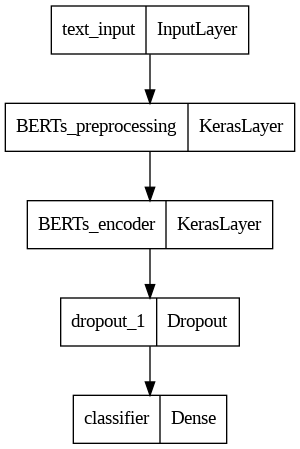

In [16]:
# Show model's architecture
tf.keras.utils.plot_model(m1_berts_classifier_model)

In [17]:
# Callbacks
m1_berts_early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
m1_berts_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# PAUSE THIS PIECE - Model trained
# Train BERTs Version 1
# import time
# m1_berts_start_time = time.time()
# print("Time: ", m1_berts_start_time)
# 
# print(f'Training model with {m1_tfhub_handle_encoder_berts}')
# m1_berts_history = m1_berts_classifier_model.fit(
#     train_ds_tiny,
#     validation_data=val_ds_tiny,
#     epochs=10,
#     callbacks=[m1_berts_early_stop, m1_berts_reduce_lr]
# )
# 
# m1_berts_end_time = time.time()
# m1_berts_total_time =  m1_berts_end_time - m1_berts_start_time
# print(f"Tiempo de entrenamiento: {m1_berts_total_time:.2f} segundos")

In [19]:
# Save training time with CPU only
m1_berts_total_time = round(1377.70/60, 2)
print(f"Model training time: {m1_berts_total_time} minutes")

Model training time: 22.96 minutes


In [20]:
# Evaluate the model with our testing set
# m1_berts_loss, m1_berts_accuracy = m1_berts_classifier_model.evaluate(test_ds_tiny)
# print(f"Test Loss: {m1_berts_loss:.4f}, Test Accuracy: {m1_berts_accuracy:.4f}")

# Save in a dictionary the validation results
m1_berts_model_validation = {"accuracy":0.4700, "loss":0.6953}
print(f"Test Accuracy: {m1_berts_model_validation['accuracy']} Test Loss: {m1_berts_model_validation['loss']}")

Test Accuracy: 0.47 Test Loss: 0.6953


In [21]:
# Set up the root directory where to store all trained models
import os
file_storage_root_directory = "/kaggle/working/"
print("Is this a directory?:", os.path.isdir(file_storage_root_directory))

Is this a directory?: True


**Exportar modelo entrenado como historial de entrenamiento**

In [22]:
# Save the trained model in directory
# from tensorflow.keras.models import load_model

# Save the trained model
# m1_path_save_berts_model = os.path.join(file_storage_root_directory, "m1_berts_trained_model.keras")
# m1_berts_classifier_model.save(m1_path_save_berts_model)

# Save training history as csv
m1_path_save_berts_history = os.path.join(file_storage_root_directory, 'm1_berts_training_history.csv')
# m1_berts_history_df = pd.DataFrame(m1_berts_history.history)

# Save the df as csv
# m1_berts_history_df.to_csv(m1_path_save_berts_history)

**Importar modelo entrenado como historial de entrenamiento**

In [23]:
# Load the file containing the model
#m1_load_berts_model = load_model(m1_path_save_berts_model)
#m1_load_berts_model.summary()

In [24]:
# Load the history results of the model
m1_load_berts_history_df = pd.read_csv(m1_path_save_berts_history)
m1_load_berts_history_df.head(5)

,Unnamed: 0,loss,binary_accuracy,val_loss,val_binary_accuracy,lr
0,0,0.790359,0.494,0.724365,0.47,0.0001
1,1,0.745664,0.486,0.745434,0.47,0.0001
2,2,0.757481,0.494,0.718430,0.47,0.0001
3,3,0.705379,0.542,0.723632,0.51,0.0001
4,4,0.563973,0.689,1.055523,0.56,0.0001


/tmp/ipykernel_35/3371889907.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


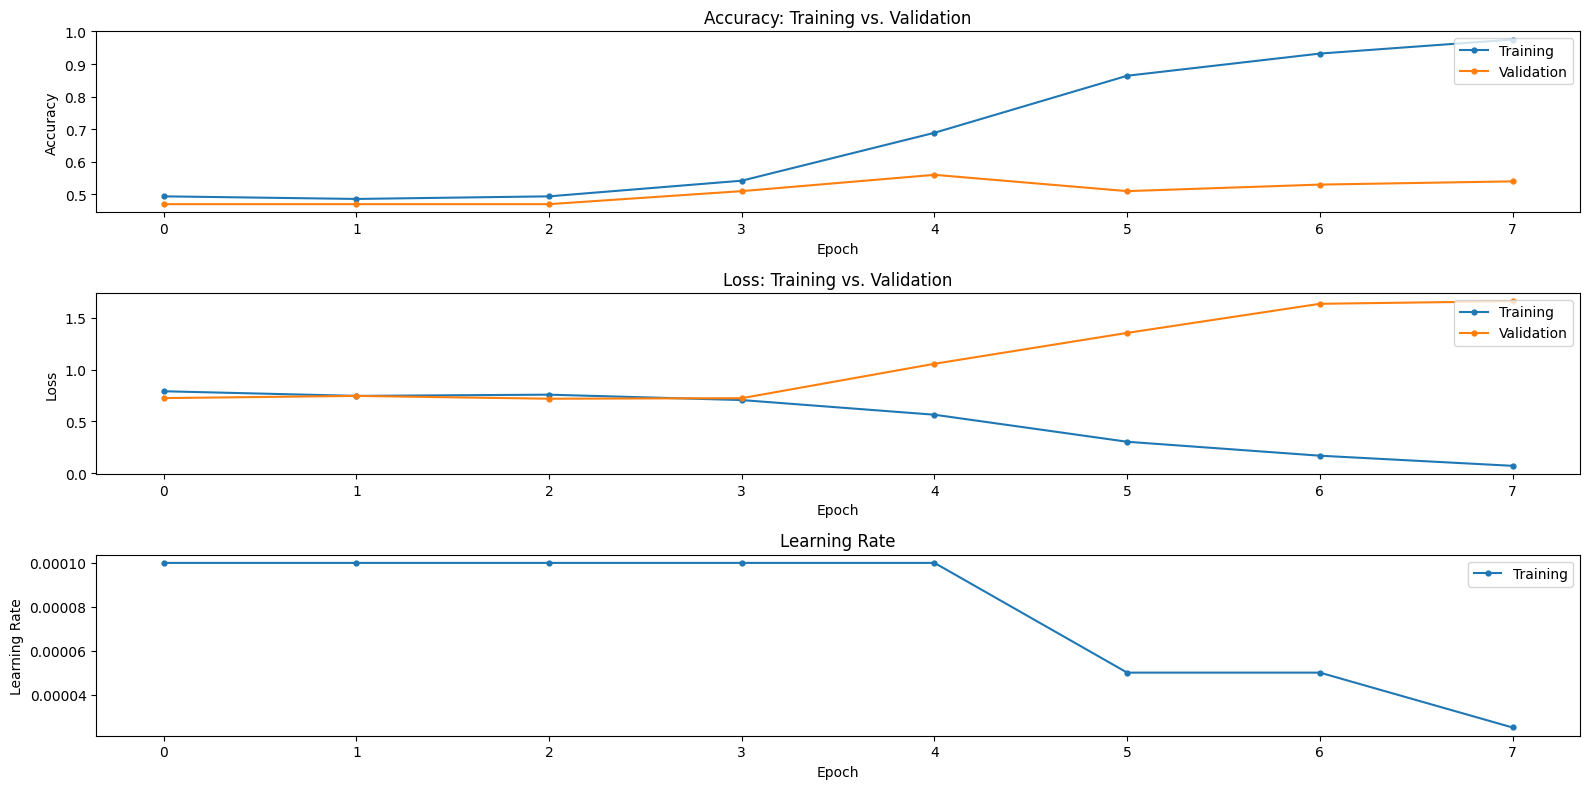

In [25]:
# Graficar Accuracy-Loss
plot_accuracy_loss_throught_epoch(m1_load_berts_history_df)

In [26]:
# Reproduce the paper table 4
df_models_results =  pd.DataFrame(columns=["model", 'accuracy'])
df_models_results.loc[0, "model"] = 'LSTM'
df_models_results.loc[0, "accuracy"] = 0.6702
df_models_results.loc[1, "model"] = 'Transformer Basic'
df_models_results.loc[1, "accuracy"] = 0.8548
df_models_results.loc[2, "model"] = 'Transformer Improved'
df_models_results.loc[2, "accuracy"] = 0.8453
df_models_results.loc[3, "model"] = 'BERTs v1'
df_models_results.loc[3, "accuracy"] = 0.47
df_models_results

,model,accuracy
0,LSTM,0.6702
1,Transformer Basic,0.8548
2,Transformer Improved,0.8453
3,BERTs v1,0.47


Memorización del conjunto de prueba. Alta distancia entre las curvas de accuracy de entrenamiento vs validacion partir de la época 3. Modelo incapaz de classificar los cometarios datos. Es inestable. No sabemos si son por los valores datos a los hiperparámetros o bien porque el conjunto de datos que estamos dando no son suficientes. Habría que investigar.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [1 pt]:</strong>

Repite el ejercicio anterior pero ahora utilizando un modelo BERT más grande. Debes utilizar un modelo que sea capaz de obtener mejores resultados que en todos los casos anteriores. Finetunear un modelo grande puede requerir varias horas.
*  Añade en la tabla de resultados, el resultado obtenido con este modelo.
*  Al igual que antes representa las gráficas de accuracy y loss.
*  Comenta los resultados y discute los tiempos de entrenamiento empleados

</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

In [27]:
# Given available models in map_name_to_handle: https://www.tensorflow.org/text/tutorials/classify_text_with_bert
# We choose Small BERT
# It uses L=6 hidden layers (i.e., Transformer blocks), a hidden size of H=768, and A=12 attention heads.

m2_model_berts = 'small_bert/bert_en_uncased_L-6_H-768_A-12'
m2_map_name_to_handle = {'small_bert/bert_en_uncased_L-6_H-768_A-12': 'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-768_A-12/1'}
m2_map_model_to_preprocess = {'small_bert/bert_en_uncased_L-6_H-768_A-12': 'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3'}

m2_tfhub_handle_encoder_berts = m2_map_name_to_handle[m2_model_berts]
m2_tfhub_handle_preprocess_berts = m2_map_model_to_preprocess[m2_model_berts]

# Construct binary text classification with BERTs
def m2_build_berts_classifier_model():
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text_input')
    
    # Load the Small BERT model for preprocessing from TF Hub into a Keras model
    preprocessing_layer = hub.KerasLayer(m2_tfhub_handle_preprocess_berts, name='BERTs_preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    
    # Load the Small BERT model for encoding from TF Hub into a Keras model
    encoder = hub.KerasLayer(m2_tfhub_handle_encoder_berts, trainable=True, name='BERTs_encoder')
    outputs = encoder(encoder_inputs)
    
    # pooled_output represents each input sequence as whole
    # Think of this as an embedding for the entire movie review
    net = outputs['pooled_output'] # [Batch size, H]
    net = tf.keras.layers.Dropout(0.2)(net)
    net = tf.keras.layers.Dense(1, activation=None, name='classifier')(net)
    return tf.keras.Model(text_input, net, name='m2_BERTs')

# Check the model runs with the output of the preprocessing
m2_berts_classifier_model = m2_build_berts_classifier_model()

text_test = ['this is such an amazing movie!']
m2_berts_raw_result = m2_berts_classifier_model(tf.constant(text_test))
print("Result m2_build_berts_classifier_model: ", tf.sigmoid(m2_berts_raw_result))

Result m2_build_berts_classifier_model:  tf.Tensor([[0.57227165]], shape=(1, 1), dtype=float32)


In [28]:
# Instantiate the class
m2_berts_classifier_model = m2_build_berts_classifier_model()

# Compile model
m2_berts_classifier_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                               loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                               metrics=[tf.metrics.BinaryAccuracy()], run_eagerly=False
                              )

In [29]:
# Show model summary
m2_berts_classifier_model.summary()

Model: "m2_BERTs"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text_input (InputLayer)     [(None,)]                    0         []                            
                                                                                                  
 BERTs_preprocessing (Keras  {'input_mask': (None, 128)   0         ['text_input[0][0]']          
 Layer)                      , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}                                                                
                                                                                           

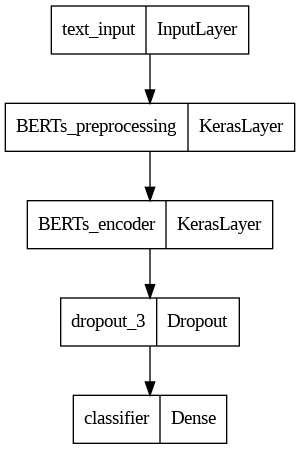

In [30]:
# Show model's architecture
tf.keras.utils.plot_model(m2_berts_classifier_model)

In [31]:
# Callbacks
m2_berts_early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
m2_berts_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# PAUSE THIS PIECE - Model trained
# Train BERTs Version 2
# import time
# m2_berts_start_time = time.time()
# print("Time: ", m2_berts_start_time)
# 
# print(f'\nTraining model with {m2_tfhub_handle_encoder_berts}')
# m2_berts_history = m2_berts_classifier_model.fit(
#     train_ds_tiny,
#     validation_data=val_ds_tiny,
#     epochs=10,
#     callbacks=[m2_berts_early_stop, m2_berts_reduce_lr]
# )
# 
# m2_berts_end_time = time.time()
# m2_berts_total_time =  m2_berts_end_time - m2_berts_start_time
# print(f"Tiempo de entrenamiento: {m2_berts_total_time:.2f} segundos")

In [32]:
# Save training time with CPU only
m2_berts_total_time = round(4287.46/60,2)
print(f"Model training time: {m2_berts_total_time} minutes")

Model training time: 71.46 minutes


In [33]:
# Evaluate the model with our testing set
# m2_berts_loss, m2_berts_accuracy = m2_berts_classifier_model.evaluate(test_ds_tiny)
# print(f"Test Loss: {m2_berts_loss:.4f}, Test Accuracy: {m2_berts_accuracy:.4f}")

# Save in a dictionary the validation results
m2_berts_model_validation = {"accuracy":0.36, "loss":1.5466}
print(f"Test Accuracy: {m2_berts_model_validation['accuracy']} Test Loss: {m2_berts_model_validation['loss']}")

Test Accuracy: 0.36 Test Loss: 1.5466


**Exportar modelo entrenado como historial de entrenamiento**


In [34]:
# Save the trained model in directory
# from tensorflow.keras.models import load_model

# Save the trained model
# m2_path_save_berts_model = os.path.join(file_storage_root_directory, "m2_berts_trained_model.keras")
# m2_berts_classifier_model.save(m2_path_save_berts_model)

# Save training history as csv
m2_path_save_berts_history = os.path.join(file_storage_root_directory, 'm2_berts_training_history.csv')
#m2_berts_history_df = pd.DataFrame(m2_berts_history.history)

# Save the df as csv
# m2_berts_history_df.to_csv(m2_path_save_berts_history)

**Importar modelo entrenado como historial de entrenamiento**

In [35]:
# Load the file containing the model
# m2_load_berts_model = load_model(m2_path_save_berts_model)
# m2_load_berts_model.summary()

In [36]:
# Load the history results of the model
m2_load_berts_history_df = pd.read_csv(m2_path_save_berts_history)
m2_load_berts_history_df.head(5)

,Unnamed: 0,loss,binary_accuracy,val_loss,val_binary_accuracy,lr
0,0,0.779652,0.518,0.743380,0.47,0.0001
1,1,0.776487,0.467,0.741216,0.47,0.0001
2,2,0.759436,0.494,0.726734,0.47,0.0001
3,3,0.747372,0.477,0.746973,0.47,0.0001
4,4,0.775961,0.482,0.749189,0.47,0.0001


/tmp/ipykernel_35/3371889907.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


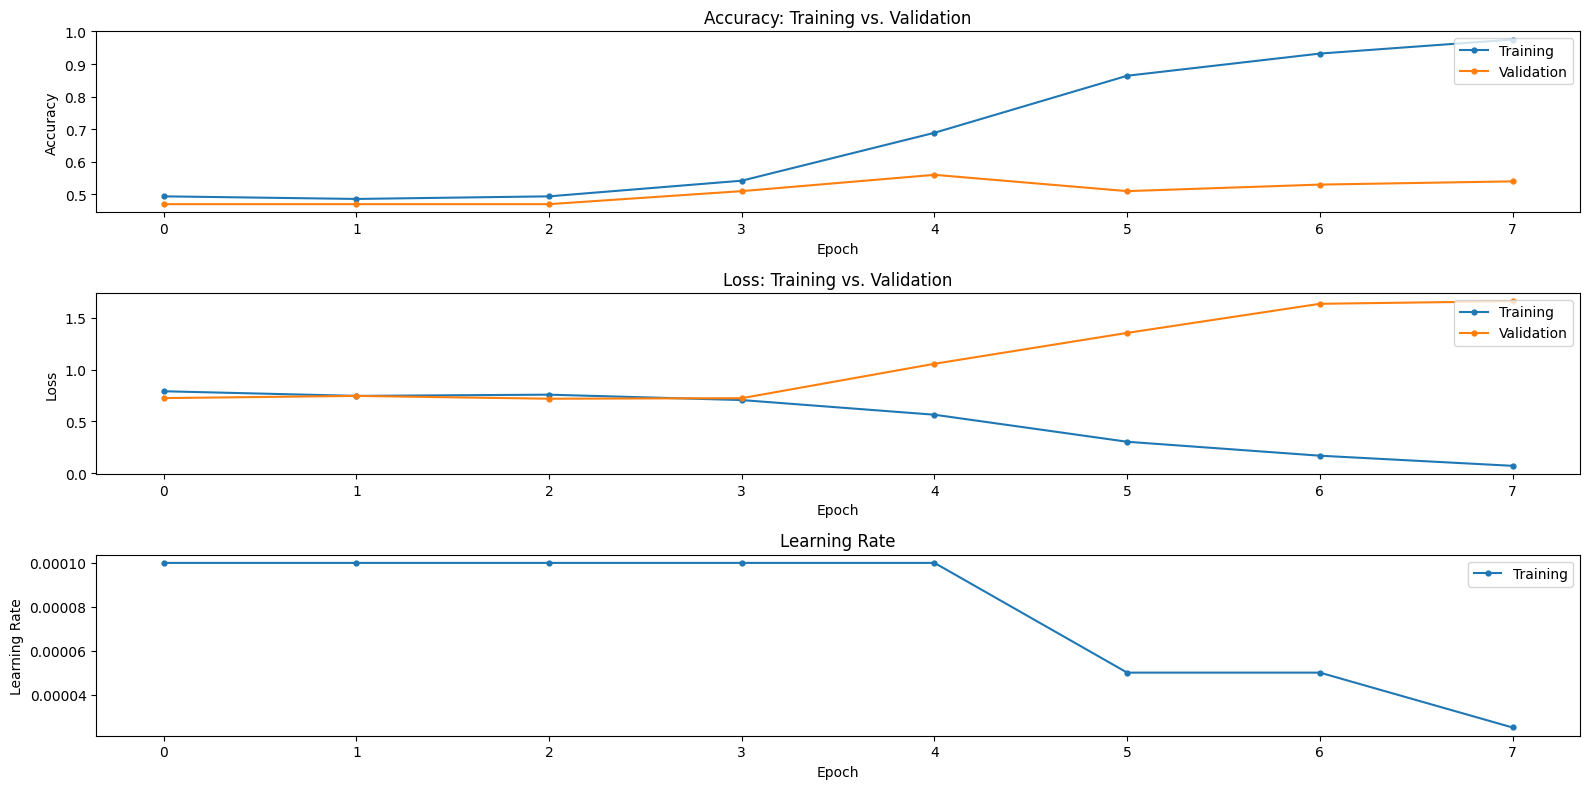

In [37]:
# Graficar Accuracy-Loss
plot_accuracy_loss_throught_epoch(m1_load_berts_history_df)

Peor rendimiento del modelo más "grande" con respecto al "pequeño" dado los mismo parámetros. Intuímos que puedes ser que su configuración no está hecho para el pequeño dataset que hemos alimentado. 

In [38]:
# Reproduce the paper table 4
df_models_results.loc[4, "model"] = 'BERTs v2'
df_models_results.loc[4, "accuracy"] = 0.36
df_models_results

,model,accuracy
0,LSTM,0.6702
1,Transformer Basic,0.8548
2,Transformer Improved,0.8453
3,BERTs v1,0.47
4,BERTs v2,0.36


## 6 Optimizando los entrenamientos. (2 puntos)
Habrás observado que una de las desventajas de las grandes arquitecturas transformers de redes neuronales es que requieren una gran potencia de cómputo para entrenarse correctamente. Esto no es sólamente un problema de tiempo, sino de dinero. El hardware y la electricidad suponenen el principal coste operativo de estas arquitecturas por lo que optimizarlas es primordial y supone una ventaja competitiva (ver el caso de DeepSeek).

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [0.5 pt]:</strong>

Repite el ejercicio anterior pero ahora prueba solo las últimas capas. Es decir, en este caso el bloque BERT se queda congelado. Puedes probar a añadir alguna capa entre el bloque BERT y la salida.
*  Añade en la tabla de resultados, el resultado obtenido con este modelo
*  Comenta los resultados y discute los tiempos de entrenamiento empleados. Es una estrategia útil? Que otras alternativas similares hay?

</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

Congelar la capa BERT significa que no vamos a usar los parámetros que se han usado para entrenar BERT. Con esto, lo que hacemos es reducir el tiempo computacional, sobretodo si solo estamos trabajando con potencia CPU (como en nuestro caso). Entonces, en este caso, solo vamos a entrenar la parte de clasificación. Añadimos solo una capa dense de 8 neuronas.

In [39]:
# Given available models in map_name_to_handle: https://www.tensorflow.org/text/tutorials/classify_text_with_bert
# We choose Small BERT
# It uses L=6 hidden layers (i.e., Transformer blocks), a hidden size of H=768, and A=12 attention heads.
m3_model_berts = 'small_bert/bert_en_uncased_L-6_H-768_A-12'
m3_map_name_to_handle = {'small_bert/bert_en_uncased_L-6_H-768_A-12': 'https://tfhub.dev/tensorflow/small_bert/bert_en_uncased_L-6_H-768_A-12/1'}
m3_map_model_to_preprocess = {'small_bert/bert_en_uncased_L-6_H-768_A-12': 'https://tfhub.dev/tensorflow/bert_en_uncased_preprocess/3'}

m3_tfhub_handle_encoder_berts = m3_map_name_to_handle[m3_model_berts]
m3_tfhub_handle_preprocess_berts = m3_map_model_to_preprocess[m3_model_berts]

# Construct binary text classification with BERTs
def m3_build_berts_classifier_model():
    text_input = tf.keras.layers.Input(shape=(), dtype=tf.string, name='text_input')
    
    # Load the Small BERT model for preprocessing from TF Hub into a Keras model
    preprocessing_layer = hub.KerasLayer(m3_tfhub_handle_preprocess_berts, name='BERTs_preprocessing')
    encoder_inputs = preprocessing_layer(text_input)
    
    # Load the Small BERT model for encoding from TF Hub into a Keras model
    # Freezing the BERT encoder setting trainable=False. 
    # This means that we won't update the weights of the BERT model during training.
    # And only train the final layers
    encoder = hub.KerasLayer(m3_tfhub_handle_encoder_berts, trainable=False, name='BERTs_encoder')
    outputs = encoder(encoder_inputs)
    # pooled_output represents each input sequence as whole 
    # Think of this as an embedding for the entire movie review
    net = outputs['pooled_output'] # [Batch size, H]
    net = tf.keras.layers.Dropout(0.2, name ='dropout')(net)
    net = keras.layers.Dense(8, activation ='relu',name = 'hidden_laryer_8')(net)
    net = tf.keras.layers.Dense(1, activation=None, name='classifier')(net)
    return tf.keras.Model(text_input, net, name='m3_freeze_BERTs')

# Check the model runs with the output of the preprocessing
m3_berts_classifier_model = m3_build_berts_classifier_model()

text_test = ['this is such an amazing movie!']
m3_berts_raw_result = m3_berts_classifier_model(tf.constant(text_test))
print("Result m3_build_berts_classifier_model: ", tf.sigmoid(m3_berts_raw_result))

Result m3_build_berts_classifier_model:  tf.Tensor([[0.5488287]], shape=(1, 1), dtype=float32)


In [40]:
# Instantiate the class
m3_berts_classifier_model = m3_build_berts_classifier_model()

# Compile model
m3_berts_classifier_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
                               loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                               metrics=[tf.metrics.BinaryAccuracy()], run_eagerly=True
                              )
# Show model summary
m3_berts_classifier_model.summary()

Model: "m3_freeze_BERTs"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 text_input (InputLayer)     [(None,)]                    0         []                            
                                                                                                  
 BERTs_preprocessing (Keras  {'input_mask': (None, 128)   0         ['text_input[0][0]']          
 Layer)                      , 'input_type_ids': (None,                                           
                              128),                                                               
                              'input_word_ids': (None,                                            
                             128)}                                                                
                                                                                    

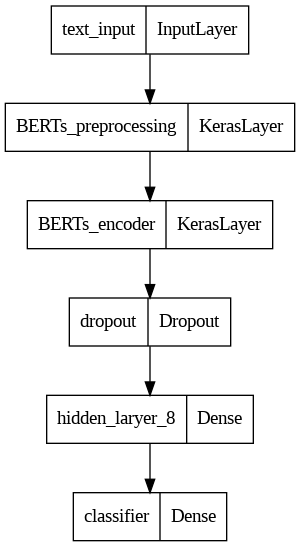

In [41]:
# Show model's architecture
tf.keras.utils.plot_model(m3_berts_classifier_model)

In [42]:
# Callbacks
m3_berts_early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
m3_berts_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# PAUSE THIS PIECE - Model trained
# Train BERTs Version 3 - FREEZE
# import time
# m3_berts_start_time = time.time()
# print(f'Time: {m3_berts_start_time}')
# print(f'Training model with {m3_tfhub_handle_encoder_berts}')
# m3_berts_history = m3_berts_classifier_model.fit(
#     train_ds_tiny,
#     validation_data=val_ds_tiny,
#     epochs=10,
#     callbacks=[m3_berts_early_stop, m3_berts_reduce_lr]
# )
# 
# m3_berts_end_time = time.time()
# m3_berts_total_time =  m3_berts_end_time - m3_berts_start_time
# print(f"Tiempo de entrenamiento: {m3_berts_total_time:.2f} segundos")

In [43]:
# Save training time with CPU only
m3_berts_total_time = round(2410.09/60,2)
print(f"Model training time: {m3_berts_total_time} minutes")

Model training time: 40.17 minutes


In [44]:
# Evaluate the model with our testing set
# m3_berts_loss, m3_berts_accuracy = m3_berts_classifier_model.evaluate(test_ds_tiny)
# print(f"Test Loss: {m3_berts_loss:.4f}, Test Accuracy: {m3_berts_accuracy:.4f}")

# Save in a dictionary the validation results
m3_berts_model_validation = {"accuracy":0.49, "loss":0.6856}
print(f"Test Accuracy: {m3_berts_model_validation['accuracy']} Test Loss: {m3_berts_model_validation['loss']}")

Test Accuracy: 0.49 Test Loss: 0.6856


**Exportar modelo entrenado como historial de entrenamiento**

In [45]:
# Save the trained model in directory
# from tensorflow.keras.models import load_model

# Save the trained model
# m3_path_save_berts_model = os.path.join(file_storage_root_directory, "m3_berts_trained_model.keras")
# m3_berts_classifier_model.save(m3_path_save_berts_model)

# Save training history as csv
m3_path_save_berts_history = os.path.join(file_storage_root_directory, 'm3_berts_training_history.csv')
# m3_berts_history_df = pd.DataFrame(m3_berts_history.history)
# m3_berts_history_df.to_csv(m3_path_save_berts_history)

**Importar modelo entrenado como historial de entrenamiento**

In [46]:
# Load the file containing the model
# m3_load_berts_model = load_model(m3_path_save_berts_model)
# m3_load_berts_model.summary()

In [47]:
# Load the history results of the model
m3_load_berts_history_df = pd.read_csv(m3_path_save_berts_history)
m3_load_berts_history_df.head(5)

,Unnamed: 0,loss,binary_accuracy,val_loss,val_binary_accuracy,lr
0,0,0.727184,0.493,0.702023,0.46,0.00010
1,1,0.697588,0.509,0.704292,0.47,0.00010
2,2,0.705410,0.504,0.705196,0.46,0.00010
3,3,0.702959,0.507,0.705134,0.45,0.00005
4,4,0.694139,0.504,0.704693,0.46,0.00005


/tmp/ipykernel_35/3371889907.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


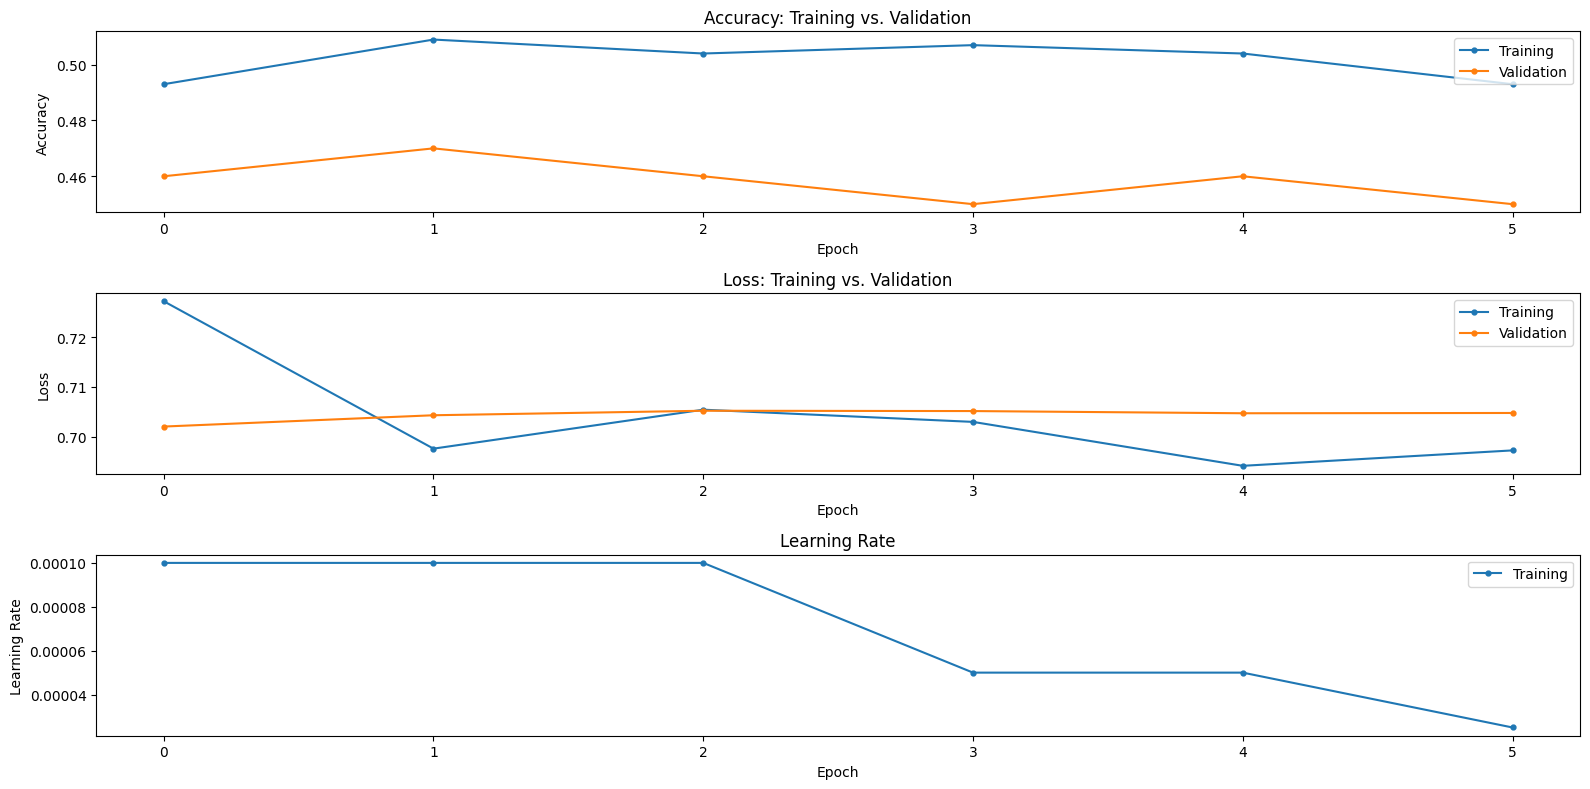

In [48]:
# Graficar Accuracy-Loss
plot_accuracy_loss_throught_epoch(m3_load_berts_history_df)

Consigue mejor rendimiento comparado a las dos experiementos previos. Aún así, la distancia entre conjunto de entrenamiento y validación sigues siendo elevada.

In [49]:
# Reproduce the paper table 4
df_models_results.loc[5, "model"] = 'BERTs v3 Freeze'
df_models_results.loc[5, "accuracy"] = 0.49
df_models_results

,model,accuracy
0,LSTM,0.6702
1,Transformer Basic,0.8548
2,Transformer Improved,0.8453
3,BERTs v1,0.47
4,BERTs v2,0.36
5,BERTs v3 Freeze,0.49


**Conclusión**

Los modelos entrenados en esta pec comparten los siguienes valores:

- dropout_rate = 0.2
- learning_rate = 1e-4
- early_stopping_patience = 5
- reduce_lr_onplateau_patience = 2

Todos los modelos downstream tienen peor rendimiento de clasificación. Hasta ahora esto es porque hemos limitado las muestras como las épocas en el entrenamiento. Por lo que habría que solo comparar los modelos Downstream entre sí dadas las distintas versiones creadas. Todos los modelos requieren un tiempo de cómputo inmenso, casi inviable para ejecutar algún tipo de optimización dadas las restricciones computacionales, conocimiento y tiempo.

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [1.5 pt]:</strong>  Catastrophic forgetting.

En la sección 5.3.3 del paper How to Fine-Tune BERT for Text Classification? https://arxiv.org/pdf/1905.05583v3 se estudia el Catastrophic forgetting. Esta situación es muy delicada en los modelos de transformers de gran escala y debe comprenderse muy bien para evitar estas situaciones

* Reproduce la figura "Figure 2: Catastrophic Forgetting" de ese artículo científico. En concreto las subfiguras c y d. Únicamente es necesario que lo hagas sobre la curva de train. El eje x de estas figuras (iterations), puedes considerar que son los batches de entrenamiento, mientras que el eje Y hace referencia al loss. No es necesario que emplees exactamente los valores de lr que se muestran en esa figura. El objetivo es que muestres un caso en el que el lr es tan grande que se produce el Catastrophic forgetting, y otro caso con otro valor en el que esto no ocurre.
</div>

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

Para este ejercicio tomamos el modelo 1 (Ejercicio 5.1). El tiempo de ejecución por cada 1K muestras es de 8 minutos mediante CPU. Esto supone para 21K muestras un total de 2h y 8 minutos por epoca y ejercicio. Si necesitamos 10 épocas mínimo para recrear el gráfico, necesitamos ¡más de 20 horas para cada ejercicio!. Por ello seguimos trabajando con 1K muestras.

Para el ejercicio 6.2 probamos learning rates: 2e-5, 3e-5, 5e-5

### Learning Rate: 2e-5

In [50]:
# Instantiate the class with new values
m4_berts_classifier_model = m1_build_berts_classifier_model()

m4_learning_rate = 2e-5

# Compile model
m4_berts_classifier_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=m4_learning_rate),
                               loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                               metrics=[tf.metrics.BinaryAccuracy()], run_eagerly=False
                              )

In [51]:
# Callbacks
m4_berts_early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
m4_berts_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# PAUSE THIS PIECE - Model trained
# Train BERTs Version 4
# import time
# m4_berts_start_time = time.time()
# 
# print(f'Training model with {m1_tfhub_handle_encoder_berts}')
# m4_berts_history = m4_berts_classifier_model.fit(
#     train_ds_tiny,
#     validation_data=val_ds_tiny,
#     epochs=10,
#     callbacks=[m4_berts_early_stop, m4_berts_reduce_lr]
# )
# 
# m4_berts_end_time = time.time()
# m4_berts_total_time =  m4_berts_end_time - m4_berts_start_time
# print(f"Tiempo de entrenamiento: {m4_berts_total_time:.2f} segundos")

In [52]:
# Save training time with CPU only
m4_berts_total_time = round(924.01/60, 2)
print(f"Training time: {m4_berts_total_time} minutos")

Training time: 15.4 minutos


In [53]:
# Evaluate the model with our testing set
# m4_berts_loss, m4_berts_accuracy = m4_berts_classifier_model.evaluate(test_ds_tiny)
# print(f"Test Loss: {m4_berts_loss:.4f}, Test Accuracy: {m4_berts_accuracy:.4f}")

# Save in a dictionary the validation results
m4_berts_model_validation = {"accuracy":0.4700, "loss":0.7071}
print(f"Test Accuracy: {m4_berts_model_validation['accuracy']} Test Loss: {m4_berts_model_validation['loss']}")

Test Accuracy: 0.47 Test Loss: 0.7071


In [54]:
# Save training history as csv
m4_path_save_berts_history = os.path.join(file_storage_root_directory, 'm4_berts_training_history.csv')
# m4_berts_history_df = pd.DataFrame(m4_berts_history.history)
# m4_berts_history_df.to_csv(m4_path_save_berts_history)
# m4_berts_history_df.head()

# Load training history
m4_load_berts_history_df = pd.read_csv(m4_path_save_berts_history)
m4_load_berts_history_df.head()

,Unnamed: 0,loss,binary_accuracy,val_loss,val_binary_accuracy,lr
0,0,0.754098,0.482,0.716178,0.47,0.00002
1,1,0.726996,0.484,0.717164,0.47,0.00002
2,2,0.686848,0.532,0.755140,0.47,0.00002
3,3,0.659943,0.572,0.757923,0.44,0.00001
4,4,0.597552,0.637,0.780946,0.42,0.00001


/tmp/ipykernel_35/3371889907.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


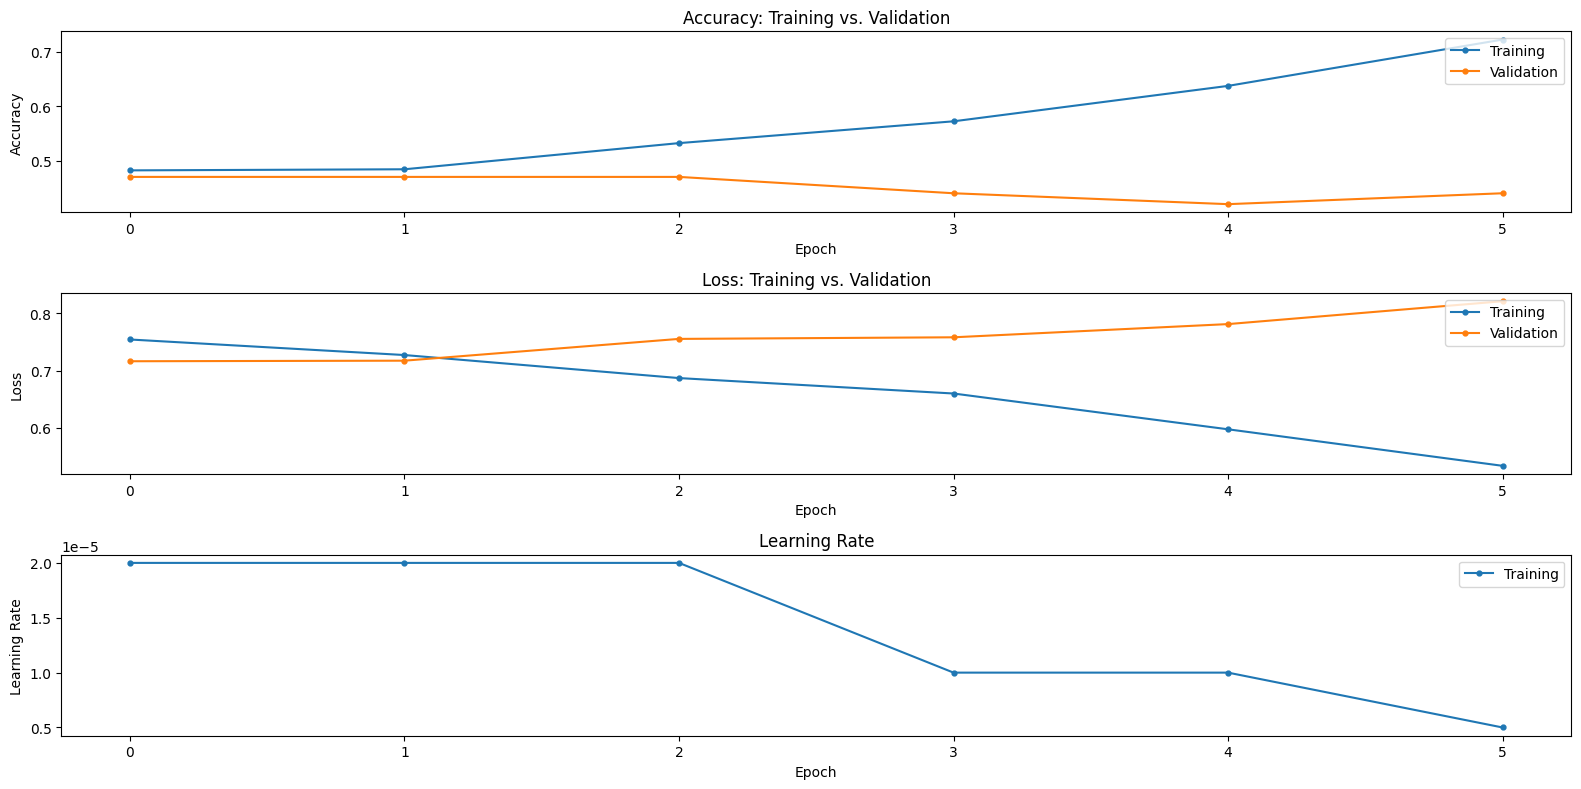

In [55]:
plot_accuracy_loss_throught_epoch(m4_load_berts_history_df)

El conjunto de entrenamiento llega a cotas del 0.7 de accuracy para un conjunto de validación cuyo máximo no supera 0.47 llegando a peores resultados conforme el modelo aprende más el conjunto.

#### Learning Rate: 3e-5

In [56]:
# Instantiate the class with new values
m5_berts_classifier_model = m1_build_berts_classifier_model()

m5_learning_rate = 3e-5

# Compile model
m5_berts_classifier_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=m5_learning_rate),
                               loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                               metrics=[tf.metrics.BinaryAccuracy()], run_eagerly=False
                              )

# Callbacks
m5_berts_early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
m5_berts_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

In [57]:
# PAUSE THIS PIECE - Model trained
# Train BERTs Version 5
# import time
# m5_berts_start_time = time.time()
# 
# print(f'Training model with {m1_tfhub_handle_encoder_berts}')
# m5_berts_history = m5_berts_classifier_model.fit(
#     train_ds_tiny,
#     validation_data=val_ds_tiny,
#     epochs=10,
#     callbacks=[m5_berts_early_stop, m5_berts_reduce_lr]
# )
# 
# m5_berts_end_time = time.time()
# m5_berts_total_time =  m5_berts_end_time - m5_berts_start_time
# print(f"Tiempo de entrenamiento: {m5_berts_total_time:.2f} segundos")

In [58]:
# Save training time with CPU only
m5_berts_total_time = round(1057.93/60, 2)
print(f"Training time: {m5_berts_total_time} minutes")

Training time: 17.63 minutes


In [59]:
# Evaluate the model with our testing set
# m5_berts_loss, m5_berts_accuracy = m5_berts_classifier_model.evaluate(test_ds_tiny)
# print(f"Test Loss: {m5_berts_loss:.4f}, Test Accuracy: {m5_berts_accuracy:.4f}")

# Save in a dictionary the validation results
m5_berts_model_validation = {"accuracy":0.4700, "loss":0.7493}
print(f"Test Accuracy: {m5_berts_model_validation['accuracy']} Test Loss: {m5_berts_model_validation['loss']}")

Test Accuracy: 0.47 Test Loss: 0.7493


In [60]:
# Save training history as csv
m5_path_save_berts_history = os.path.join(file_storage_root_directory, 'm5_berts_training_history.csv')
# m5_berts_history_df = pd.DataFrame(m5_berts_history.history)
# m5_berts_history_df.to_csv(m5_path_save_berts_history)
# m5_berts_history_df.head()

# Load training history
m5_load_berts_history_df = pd.read_csv(m5_path_save_berts_history)
m5_load_berts_history_df.head()

,Unnamed: 0,loss,binary_accuracy,val_loss,val_binary_accuracy,lr
0,0,0.771899,0.501,0.751048,0.47,0.000030
1,1,0.723597,0.505,0.737653,0.47,0.000030
2,2,0.679920,0.559,0.768385,0.47,0.000030
3,3,0.629361,0.606,0.784675,0.47,0.000030
4,4,0.465070,0.765,0.820413,0.47,0.000015


/tmp/ipykernel_35/3371889907.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


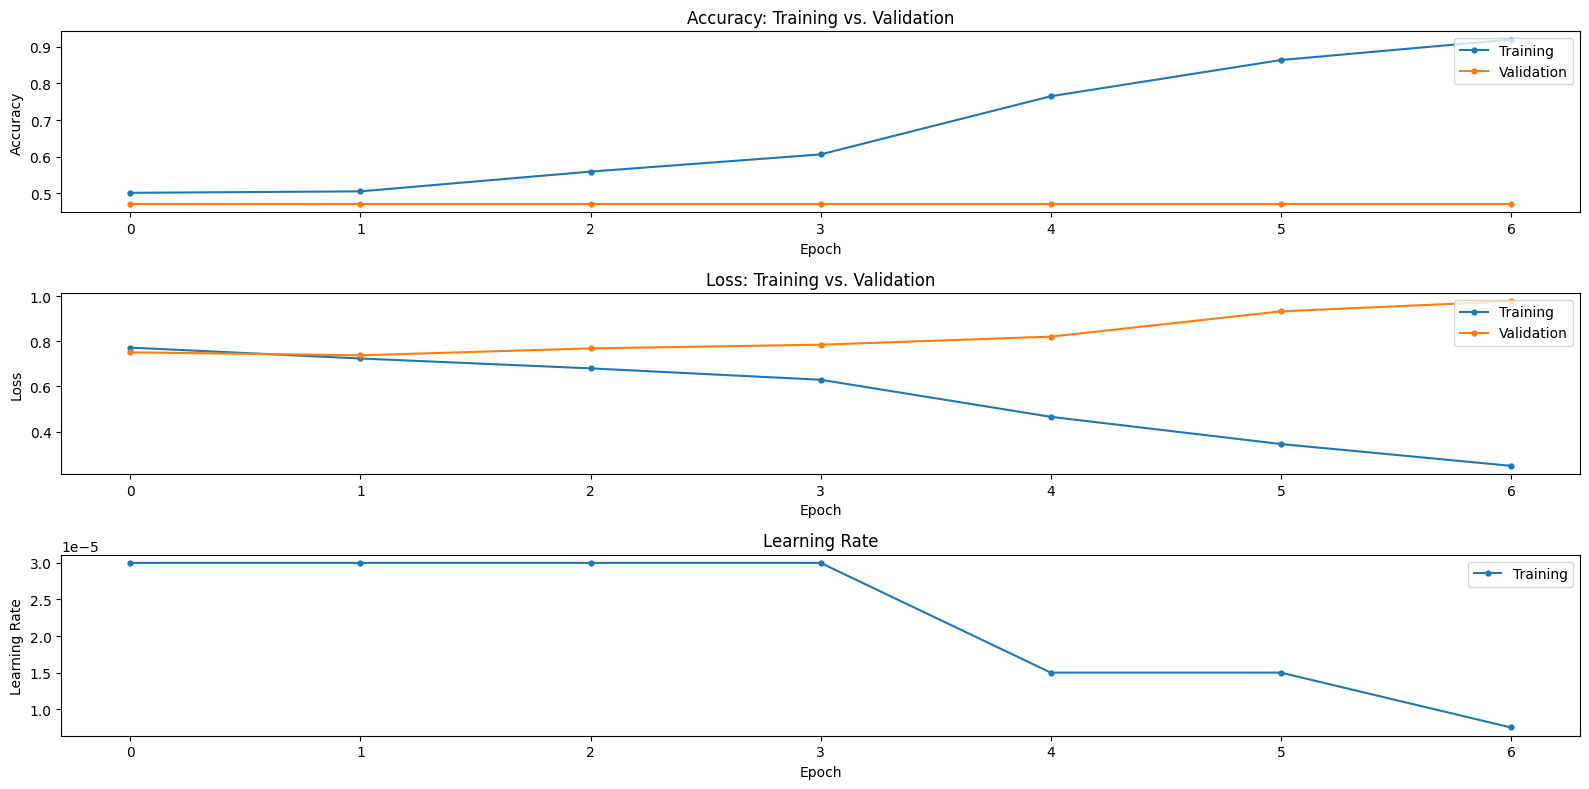

In [61]:
plot_accuracy_loss_throught_epoch(m5_load_berts_history_df)

El conjunto de entrenamiento llega a cotas del 0.9 de accuracy para un conjunto de validación cosntante de 0.47

#### Learning Rate: 5e-5

In [62]:
# Instantiate the class with new values
m6_berts_classifier_model = m1_build_berts_classifier_model()

m6_learning_rate = 5e-5
# Compile model
m6_berts_classifier_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=m6_learning_rate),
                               loss=tf.keras.losses.BinaryCrossentropy(from_logits=True),
                               metrics=[tf.metrics.BinaryAccuracy()], run_eagerly=False
                              )

# Callbacks
m6_berts_early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
m6_berts_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

In [63]:
# Callbacks
m6_berts_early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
m6_berts_reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, verbose=1)

# PAUSE THIS PIECE - Model trained
# Train BERTs Version 6
# import time
# m6_berts_start_time = time.time()
# 
# print(f'Training model with {m1_tfhub_handle_encoder_berts}')
# m6_berts_history = m6_berts_classifier_model.fit(
#     train_ds_tiny,
#     validation_data=val_ds_tiny,
#     epochs=10,
#     callbacks=[m6_berts_early_stop, m6_berts_reduce_lr]
# )
# 
# m6_berts_end_time = time.time()
# m6_berts_total_time =  m6_berts_end_time - m6_berts_start_time
# print(f"Tiempo de entrenamiento: {m6_berts_total_time:.2f} segundos")

In [64]:
# Save training time with CPU only
m6_berts_total_time = round(1086.94/60,2)
print(f"Training time: {m6_berts_total_time} minutes")

Training time: 18.12 minutes


In [65]:
# Evaluate the model with our testing set
# m6_berts_loss, m6_berts_accuracy = m6_berts_classifier_model.evaluate(test_ds_tiny)
# print(f"Test Loss: {m6_berts_loss:.4f}, Test Accuracy: {m6_berts_accuracy:.4f}")

# Save in a dictionary the validation results
m6_berts_model_validation = {"accuracy":0.47, "loss":0.7089}
print(f"Test Accuracy: {m6_berts_model_validation['accuracy']} Test Loss: {m6_berts_model_validation['loss']}")

Test Accuracy: 0.47 Test Loss: 0.7089


In [66]:
# Save training history as csv
m6_path_save_berts_history = os.path.join(file_storage_root_directory, 'm6_berts_training_history.csv')
# m6_berts_history_df = pd.DataFrame(m6_berts_history.history)
# m6_berts_history_df.to_csv(m6_path_save_berts_history)
# m6_berts_history_df.head()

# Load training history
m6_load_berts_history_df = pd.read_csv(m6_path_save_berts_history)
m6_load_berts_history_df.head()

,Unnamed: 0,loss,binary_accuracy,val_loss,val_binary_accuracy,lr
0,0,0.775393,0.510,0.733229,0.47,0.000050
1,1,0.734947,0.496,0.728232,0.47,0.000050
2,2,0.700499,0.549,0.762794,0.47,0.000050
3,3,0.600810,0.646,0.937469,0.51,0.000050
4,4,0.399545,0.825,0.871417,0.57,0.000025


/tmp/ipykernel_35/3371889907.py:42: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


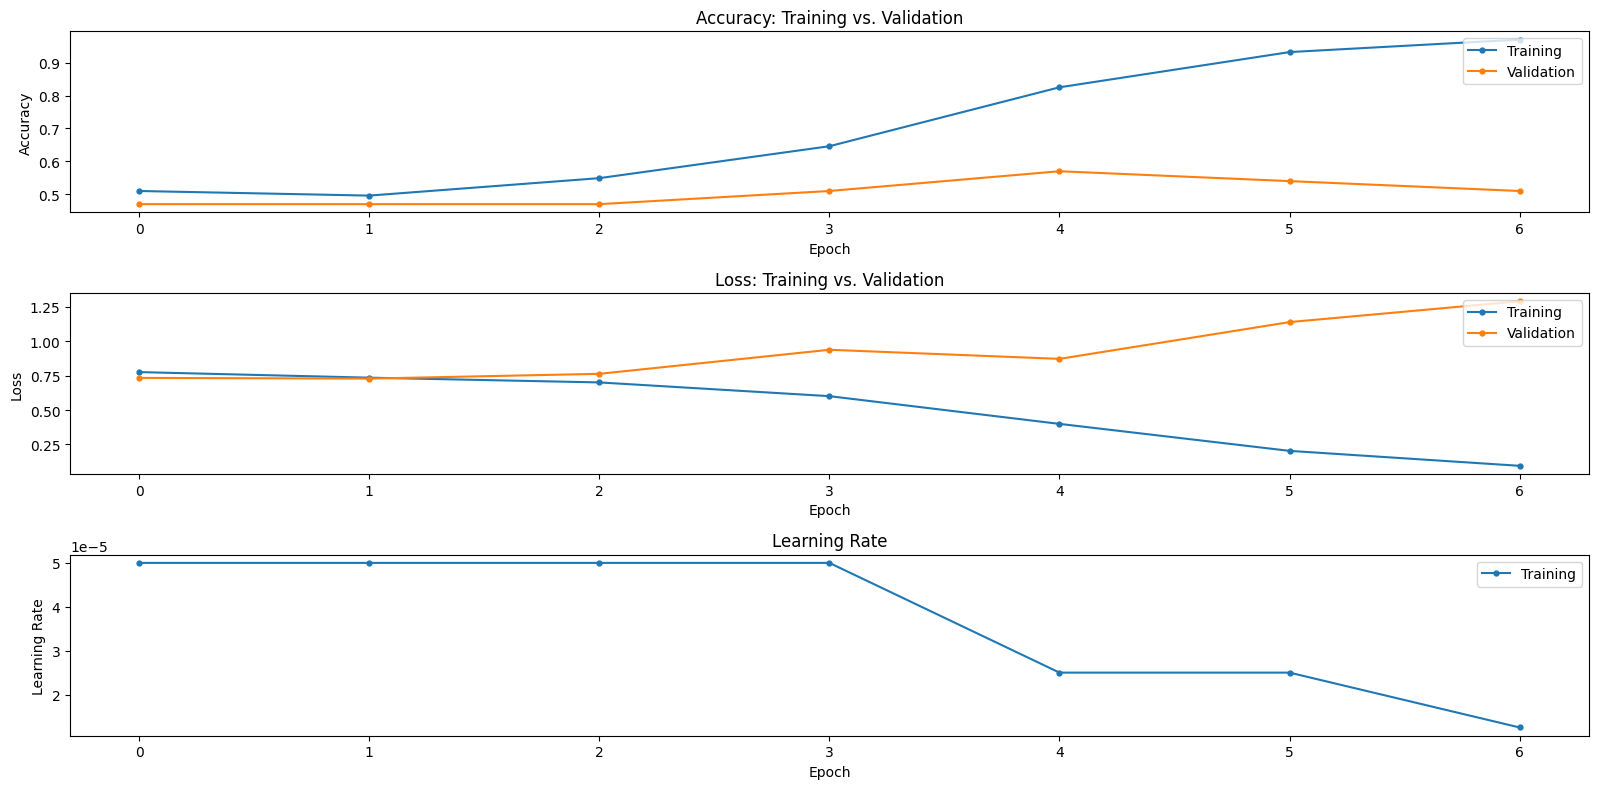

In [67]:
plot_accuracy_loss_throught_epoch(m6_load_berts_history_df)

El conjunto de entrenamiento llega a cotas del 0.9 de accuracy para un conjunto de validación constante de 0.48.

**Conclusión** 

Todos los modelos presentan accuracy=0.47 en este experimento. Sin embargo su comportamiento en los entrenamientos es distinto.
En este caso, a mayor learning rate el conjunto de entrenamiento obtiene accuracy cercanos al 0.9 mientras que el conjunto de validación empeora o se mantiene constante sin cambios. De modo que, todos los modelos entrenados tienden a "memorizar" los datos imputados, de forma que no es capaz de clasificar un nuevo conjunto. Si tuvieramos que entrenar un nuevo modelo, sería usar el learning rate al rededor de 2e-5 con todo el conjunto en más de 10 épocas porque vemos que en casos superiores el conjunto de validación apenas cambia.

No procedemos al ejercicio 7. Consideramos que cualquier otra variación no proporcionará un mejor resultado dada las limitaciones (recurso computacional, y tiempo dedicado a esta pec). Hemos probado ejecutar los modelos con el conjunto entero de datos con solo una época obteniendo como máximo accuracy de 0.5. Por tanto, hay varios conceptos que madurar.

In [68]:
df_models_results.loc[6, "model"] = 'BERTs v4 - lr-2e5'
df_models_results.loc[6, "accuracy"] = 0.47
df_models_results.loc[7, "model"] = 'BERTs v5 - lr-3e-5'
df_models_results.loc[7, "accuracy"] = 0.47
df_models_results.loc[8, "model"] = 'BERTs v6 - lr-5e-5'
df_models_results.loc[8, "accuracy"] = 0.47
df_models_results

,model,accuracy
0,LSTM,0.6702
1,Transformer Basic,0.8548
2,Transformer Improved,0.8453
3,BERTs v1,0.47
4,BERTs v2,0.36
5,BERTs v3 Freeze,0.49
6,BERTs v4 - lr-2e5,0.47
7,BERTs v5 - lr-3e-5,0.47
8,BERTs v6 - lr-5e-5,0.47


## 7 Estrategia final. (1 punto)

<div style="background-color: #EDF7FF; border-color: #7C9DBF; border-left: 5px solid #7C9DBF; padding: 0.5em;">
<p><strong>Ejercicio [1 pt]:</strong>
Con todo lo que has aprendido. Finalmente entrena un modelo de BERT para clasificación e intenta obtener los mejores resultados posibles.

<div style="background-color: #fcf2f2; border-color: #dfb5b4; border-left: 5px solid #dfb5b4; padding: 0.5em;">
<p><strong>Solución:</strong> </p>
</div>

## Recursos

- Anishnama. Understanding LSTM: Architecture, Pros and Cons, and Implementation. (2023). [Medium]. Localización: https://medium.com/@anishnama20/understanding-lstm-architecture-pros-and-cons-and-implementation-3e0cca194094 (Consultado en: 10 de Mayo 2025)

- lucasew, machine learning articles - classifying IMDB. [GitHub]. Localicación: https://github.com/christianversloot/machine-learning-articles/blob/main/classifying-imdb-sentiment-with-keras-and-embeddings-dropout-conv1d.md (Consultado en: 10 de Mayo 2025)

- Packt, Deep Learning with TensorFlow & Keras (2022). [YouTube]. Localización: https://www.youtube.com/watch?v=5E71_AxS4jw (Consultado en: 10 de Mayo 2025)

- IGA PR, Text sentiment classification using transformer neural network with Keras in Python. [YouTube]. Localización: https://www.youtube.com/watch?v=31jVXC4uHks (Consultado en: 12 de Mayo 2025)

- TensorFlow, Classify text with BERT. Localización: https://www.tensorflow.org/text/tutorials/classify_text_with_bert (Consultado en: 14 de Mayo 2025)

- THAREESH PRABAKARAN, Quora Questions Classification with FineTuned-BERT (2025), [Kaggle], Localización: https://www.kaggle.com/code/thareeshprabakaran/quora-questions-classification-with-finetuned-bert
(Consultado en: 15 de Mayo 2025)

- WAHAJ RAZA, NLP in Action: Analyzing Sentiments of IMDB Movie.[Kaggle]. Localización: https://www.kaggle.com/code/swahajraza/nlp-in-action-analyzing-sentiments-of-imdb-movie (Consultado en: 15 de Mayo 2025)